In [ ]:
# Import relevant packages
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import math
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [ ]:
# Read in merged and cleaned energy and weather dataframe
energy_weather = pd.read_csv('../../data/processed/energy_weather_merged.csv')
energy_weather

,time,date,hour,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,gen_solar,...,snow_3h_Bilbao,snow_3h_Madrid,snow_3h_Seville,snow_3h_Valencia,clouds_all_Barcelona,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Seville,clouds_all_Valencia,temp_avg
0,2014-12-31 23:00:00+00:00,2014-12-31,23,17.0,6436.0,26118.0,25385.0,50.10,65.41,49.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-0.658537
1,2015-01-01 00:00:00+00:00,2015-01-01,0,16.0,5856.0,24934.0,24382.0,48.10,64.92,50.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-0.637300
2,2015-01-01 01:00:00+00:00,2015-01-01,1,8.0,5454.0,23515.0,22734.0,47.33,64.48,50.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-1.050862
3,2015-01-01 02:00:00+00:00,2015-01-01,2,2.0,5151.0,22642.0,21286.0,42.27,59.32,50.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-1.060531
4,2015-01-01 03:00:00+00:00,2015-01-01,3,9.0,4861.0,21785.0,20264.0,38.41,56.04,42.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-1.004100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 18:00:00+00:00,2018-12-31,18,96.0,3253.0,30619.0,30653.0,68.85,77.02,85.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,11.320000
35060,2018-12-31 19:00:00+00:00,2018-12-31,19,51.0,3353.0,29932.0,29735.0,68.40,76.16,33.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,9.144000
35061,2018-12-31 20:00:00+00:00,2018-12-31,20,36.0,3404.0,27903.0,28071.0,66.88,74.30,31.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,7.700000
35062,2018-12-31 21:00:00+00:00,2018-12-31,21,29.0,3273.0,25450.0,25801.0,63.93,69.89,31.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,6.568000


In [3]:
energy_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             35064 non-null  str    
 1   date                             35064 non-null  str    
 2   hour                             35064 non-null  int64  
 3   forecast solar day ahead         35064 non-null  float64
 4   forecast wind onshore day ahead  35064 non-null  float64
 5   total load forecast              35064 non-null  float64
 6   total load actual                35064 non-null  float64
 7   price day ahead                  35064 non-null  float64
 8   price actual                     35064 non-null  float64
 9   gen_solar                        35064 non-null  float64
 10  gen_wind                         35064 non-null  float64
 11  gen_hydro                        35064 non-null  float64
 12  gen_pumped_hydro             

In [5]:
# Define target columns
target_cols = [
    'gen_solar',
    'gen_wind',
    'total load actual',
    'price actual',
    'price day ahead'
]

# drop forecast columns (not available at prediction time)
forecast_cols = [
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
    'total load forecast'
]

# Columns to NOT scale with training dataset (identifiers + targets + forecasts)
non_scale_cols = ['time', 'date', 'city_name', 'hour'] + \
                  target_cols + forecast_cols

# Get training feature columns to scale only
scale_cols = [
    col for col in energy_weather.columns
    if col not in non_scale_cols
    and energy_weather[col].dtype in ['float64', 'int64', 'int32']
]

print(f"Feature columns to scale ({len(scale_cols)}):")
print(scale_cols)

print(f"\nTarget columns (NOT scaled here):")
print(target_cols)

print(f"\nDropped forecast columns:")
print(forecast_cols)

Feature columns to scale (51):
['gen_hydro', 'gen_pumped_hydro', 'gen_fossil', 'gen_nuclear', 'gen_other', 'temp_Barcelona', 'temp_Bilbao', 'temp_Madrid', 'temp_Seville', 'temp_Valencia', 'pressure_Barcelona', 'pressure_Bilbao', 'pressure_Madrid', 'pressure_Seville', 'pressure_Valencia', 'humidity_Barcelona', 'humidity_Bilbao', 'humidity_Madrid', 'humidity_Seville', 'humidity_Valencia', 'wind_speed_Barcelona', 'wind_speed_Bilbao', 'wind_speed_Madrid', 'wind_speed_Seville', 'wind_speed_Valencia', 'wind_deg_Barcelona', 'wind_deg_Bilbao', 'wind_deg_Madrid', 'wind_deg_Seville', 'wind_deg_Valencia', 'rain_1h_Barcelona', 'rain_1h_Bilbao', 'rain_1h_Madrid', 'rain_1h_Seville', 'rain_1h_Valencia', 'rain_3h_Barcelona', 'rain_3h_Bilbao', 'rain_3h_Madrid', 'rain_3h_Seville', 'rain_3h_Valencia', 'snow_3h_Barcelona', 'snow_3h_Bilbao', 'snow_3h_Madrid', 'snow_3h_Seville', 'snow_3h_Valencia', 'clouds_all_Barcelona', 'clouds_all_Bilbao', 'clouds_all_Madrid', 'clouds_all_Seville', 'clouds_all_Valencia',

In [13]:
energy_weather.columns

Index(['time', 'date', 'hour', 'forecast solar day ahead',
       'forecast wind onshore day ahead', 'total load forecast',
       'total load actual', 'price day ahead', 'price actual', 'gen_solar',
       'gen_wind', 'gen_hydro', 'gen_pumped_hydro', 'gen_fossil',
       'gen_nuclear', 'gen_other', 'temp_Barcelona', 'temp_Bilbao',
       'temp_Madrid', 'temp_Seville', 'temp_Valencia', 'pressure_Barcelona',
       'pressure_Bilbao', 'pressure_Madrid', 'pressure_Seville',
       'pressure_Valencia', 'humidity_Barcelona', 'humidity_Bilbao',
       'humidity_Madrid', 'humidity_Seville', 'humidity_Valencia',
       'wind_speed_Barcelona', 'wind_speed_Bilbao', 'wind_speed_Madrid',
       'wind_speed_Seville', 'wind_speed_Valencia', 'wind_deg_Barcelona',
       'wind_deg_Bilbao', 'wind_deg_Madrid', 'wind_deg_Seville',
       'wind_deg_Valencia', 'rain_1h_Barcelona', 'rain_1h_Bilbao',
       'rain_1h_Madrid', 'rain_1h_Seville', 'rain_1h_Valencia',
       'rain_3h_Barcelona', 'rain_3h_Bilbao',

In [17]:
# Ensure that time and date are converted to datetime
energy_weather['time'] = pd.to_datetime(energy_weather['time'], utc=True)
energy_weather['date'] = pd.to_datetime(energy_weather['date'])

# Cyclical Time Features
energy_weather['hour_sin']   = np.sin(2 * np.pi * energy_weather['hour'] / 24)
energy_weather['hour_cos']   = np.cos(2 * np.pi * energy_weather['hour'] / 24)

energy_weather['day_of_week'] = pd.to_datetime(energy_weather['date']).dt.dayofweek
energy_weather['day_sin']    = np.sin(2 * np.pi * energy_weather['day_of_week'] / 7)
energy_weather['day_cos']    = np.cos(2 * np.pi * energy_weather['day_of_week'] / 7)

energy_weather['month']      = pd.to_datetime(energy_weather['date']).dt.month
energy_weather['month_sin']  = np.sin(2 * np.pi * energy_weather['month'] / 12)
energy_weather['month_cos']  = np.cos(2 * np.pi * energy_weather['month'] / 12)

energy_weather['is_weekend'] = (energy_weather['day_of_week'] >= 5).astype(int)

# Lag Features for all targets
lag_hours = [1, 2, 3, 24, 48]

for target in target_cols:
    col_name = target.replace(' ', '_')
    for lag in lag_hours:
        energy_weather[f'{col_name}_lag_{lag}'] = \
            energy_weather[target].shift(lag)

# Drop NaN rows created by lagging
energy_weather = energy_weather.dropna().reset_index(drop=True)

print(f"Shape after adding features: {energy_weather.shape}")

# Update feature_cols to include new features 
sin_cos_cols = [
    'hour_sin', 'hour_cos',
    'day_sin',  'day_cos',
    'month_sin','month_cos',
    'is_weekend'
]

lag_cols = [
    f"{target.replace(' ', '_')}_lag_{lag}"
    for target in target_cols
    for lag in lag_hours
]

# Updated full feature list
feature_cols = [
    # Original generation features
    'gen_hydro',
    'gen_pumped_hydro',
    'gen_fossil',
    'gen_nuclear',
    'gen_other',
    # Weather features
    'temp_Barcelona', 'temp_Bilbao', 'temp_Madrid', 'temp_Seville', 'temp_Valencia', 
    'pressure_Barcelona', 'pressure_Bilbao', 'pressure_Madrid', 'pressure_Seville', 'pressure_Valencia', 
    'humidity_Barcelona', 'humidity_Bilbao', 'humidity_Madrid', 'humidity_Seville', 'humidity_Valencia',
    'wind_speed_Barcelona', 'wind_speed_Bilbao', 'wind_speed_Madrid', 'wind_speed_Seville', 'wind_speed_Valencia', 
    'wind_deg_Barcelona', 'wind_deg_Bilbao', 'wind_deg_Madrid', 'wind_deg_Seville', 'wind_deg_Valencia', 
    'rain_1h_Barcelona', 'rain_1h_Bilbao', 'rain_1h_Madrid', 'rain_1h_Seville', 'rain_1h_Valencia',
    'rain_3h_Barcelona', 'rain_3h_Bilbao', 'rain_3h_Madrid', 'rain_3h_Seville', 'rain_3h_Valencia', 
    'snow_3h_Barcelona', 'snow_3h_Bilbao', 'snow_3h_Madrid', 'snow_3h_Seville', 'snow_3h_Valencia', 
    'clouds_all_Barcelona', 'clouds_all_Bilbao', 'clouds_all_Madrid', 'clouds_all_Seville', 'clouds_all_Valencia',
    'temp_avg',
    # Cyclical time features (NOT scaled — already in [-1, 1])
    'hour_sin', 'hour_cos',
    'day_sin',  'day_cos',
    'month_sin','month_cos',
    'is_weekend'
] + lag_cols  # lag features of all targets

print(f"\nFeature breakdown:")
print(f"  Original features : 23")
print(f"  Sin/cos + weekend : {len(sin_cos_cols)}")
print(f"  Lag features      : {len(lag_cols)}  "
      f"({len(target_cols)} targets × {len(lag_hours)} lags)")
print(f"  Total features    : {len(feature_cols)}")


#  Scale columns — sin/cos and lags need different treatment
# Sin/cos already bounded [-1,1] — don't scale
# Lag features are on same scale as targets — scale them

scale_cols = [
    col for col in feature_cols
    if col not in sin_cos_cols   # skip sin/cos
]

no_scale_cols = sin_cos_cols     # these stay as-is

print(f"\nColumns to scale   : {len(scale_cols)}")
print(f"Columns NOT scaled : {len(no_scale_cols)} (sin/cos features)")

Shape after adding features: (34872, 96)

Feature breakdown:
  Original features : 23
  Sin/cos + weekend : 7
  Lag features      : 25  (5 targets × 5 lags)
  Total features    : 83

Columns to scale   : 76
Columns NOT scaled : 7 (sin/cos features)


In [18]:
# Check lag alignment
sample = energy_weather[['time', 
                          'price actual',
                          'price_actual_lag_1',
                          'price_actual_lag_24']].iloc[50:55]
print(sample.to_string())

                        time  price actual  price_actual_lag_1  price_actual_lag_24
50 2015-01-11 01:00:00+00:00         53.36               54.98                55.97
51 2015-01-11 02:00:00+00:00         52.62               53.36                55.03
52 2015-01-11 03:00:00+00:00         49.17               52.62                54.53
53 2015-01-11 04:00:00+00:00         47.97               49.17                55.44
54 2015-01-11 05:00:00+00:00         49.10               47.97                57.22


In [31]:

# # Columns to skip (non-numeric or identifiers)
# non_scale_cols = ['time', 'date', 'city_name', 'hour']

# # Get columns to scale based on your actual dtypes
# scale_cols = [
#     col for col in energy_weather.columns
#     if col not in non_scale_cols
#     and energy_weather[col].dtype in ['float64', 'int64', 'int32']
# ]

# print(f"Columns to scale ({len(scale_cols)}):")
# print(scale_cols)

In [32]:

# # 1. Define column groups
# target_cols = [
#     'generation solar',
#     'generation wind onshore',
#     'total load actual',
#     'price actual',
#     'price day ahead'
# ]

# forecast_cols = [
#     'forecast solar day ahead',
#     'forecast wind onshore day ahead',
#     'total load forecast'
# ]

# identifier_cols = ['time', 'date', 'city_name', 'hour']

# feature_cols = [
#     'generation biomass',
#     'generation fossil brown coal/lignite',
#     'generation fossil gas',
#     'generation fossil hard coal',
#     'generation fossil oil',
#     'generation hydro pumped storage consumption',
#     'generation hydro run-of-river and poundage',
#     'generation hydro water reservoir',
#     'generation nuclear',
#     'generation other',
#     'generation other renewable',
#     'generation waste',
#     'temp', 'temp_min', 'temp_max',
#     'pressure', 'humidity', 'wind_speed',
#     'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all'
# ]

# print(f"Features : {len(feature_cols)}")
# print(f"Targets  : {len(target_cols)}")
# print(f"Dropped  : {len(forecast_cols)}")

# # 2. Sort by time
# energy_weather = energy_weather.sort_values('time').reset_index(drop=True)
# energy_weather

In [24]:
# creating Folds and Normalization Min-max scaler
from sklearn.preprocessing import MinMaxScaler

# Walk-forward folds
# suggested 5 but we can try different numbers to see how it affects the 
# each fold has 70% training and 15% val and 15 %testing 

N_SPLITS   = 5
total_rows = len(energy_weather)
folds      = []

for fold in range(N_SPLITS):

    # Growing window — each fold uses more data
    fold_size = int(total_rows * (fold + 1) / N_SPLITS)
    train_end = int(fold_size * 0.70)
    val_end   = int(fold_size * 0.85)

    df_train  = energy_weather.iloc[:train_end].copy()
    df_val    = energy_weather.iloc[train_end:val_end].copy()
    df_test   = energy_weather.iloc[val_end:fold_size].copy()

    # Scale features (X)
    scaler_X  = MinMaxScaler()
    scaler_X.fit(df_train[scale_cols])
    #Each set of the dataset is scaled separately to avoid data leakage 
    # claude suggested
    X_train_scaled   = scaler_X.transform(df_train[scale_cols])        # updated to exclude sin,cos cyclical time features
    X_val_scaled     = scaler_X.transform(df_val[scale_cols])          # updated to exclude sin,cos cyclical time features
    X_test_scaled    = scaler_X.transform(df_test[scale_cols])         # updated to exclude sin,cos cyclical time features

    # Append unscaled cyclical columns to full train, val, test sets
    X_train = np.hstack([
        X_train_scaled,
        df_train[no_scale_cols].values])
    X_val = np.hstack([
        X_val_scaled,
        df_val[no_scale_cols].values])
    X_test = np.hstack([
        X_test_scaled,
        df_test[no_scale_cols].values])

    # Scale each target (y) separately 
    target_scalers = {}
    y_train_dict   = {}
    y_val_dict     = {}
    y_test_dict    = {}

    for target in target_cols:
        scaler_y = MinMaxScaler()
        scaler_y.fit(df_train[[target]])

        y_train_dict[target] = scaler_y.transform(df_train[[target]])
        y_val_dict[target]   = scaler_y.transform(df_val[[target]])
        y_test_dict[target]  = scaler_y.transform(df_test[[target]])
        target_scalers[target] = scaler_y

    # 6. Store fold
    folds.append({
        'fold'           : fold + 1,
        'X_train'        : X_train,
        'X_val'          : X_val,
        'X_test'         : X_test,
        'y_train'        : y_train_dict,
        'y_val'          : y_val_dict,
        'y_test'         : y_test_dict,
        'scaler_X'       : scaler_X,
        'target_scalers' : target_scalers,
        'train_dates'    : df_train['time'].values,
        'val_dates'      : df_val['time'].values,
        'test_dates'     : df_test['time'].values
    })

    total = len(df_train) + len(df_val) + len(df_test)
    print(f"\nFold {fold+1}:")
    print(f"  Train : {len(df_train):,} rows "
          f"({df_train['time'].min().date()} → "
          f"{df_train['time'].max().date()}) "
          f"[{len(df_train)/total*100:.1f}%]")
    print(f"  Val   : {len(df_val):,} rows "
          f"({df_val['time'].min().date()} → "
          f"{df_val['time'].max().date()}) "
          f"[{len(df_val)/total*100:.1f}%]")
    print(f"  Test  : {len(df_test):,} rows "
          f"({df_test['time'].min().date()} → "
          f"{df_test['time'].max().date()}) "
          f"[{len(df_test)/total*100:.1f}%]")

print(f"\n{len(folds)} folds created")


Fold 1:
  Train : 4,881 rows (2015-01-08 → 2015-07-31) [70.0%]
  Val   : 1,046 rows (2015-07-31 → 2015-09-12) [15.0%]
  Test  : 1,047 rows (2015-09-12 → 2015-10-26) [15.0%]

Fold 2:
  Train : 9,763 rows (2015-01-08 → 2016-02-19) [70.0%]
  Val   : 2,092 rows (2016-02-19 → 2016-05-16) [15.0%]
  Test  : 2,093 rows (2016-05-16 → 2016-08-12) [15.0%]

Fold 3:
  Train : 14,646 rows (2015-01-08 → 2016-09-10) [70.0%]
  Val   : 3,138 rows (2016-09-10 → 2017-01-18) [15.0%]
  Test  : 3,139 rows (2017-01-18 → 2017-05-29) [15.0%]

Fold 4:
  Train : 19,527 rows (2015-01-08 → 2017-04-01) [70.0%]
  Val   : 4,185 rows (2017-04-01 → 2017-09-22) [15.0%]
  Test  : 4,185 rows (2017-09-22 → 2018-03-16) [15.0%]

Fold 5:
  Train : 24,410 rows (2015-01-08 → 2017-10-22) [70.0%]
  Val   : 5,231 rows (2017-10-22 → 2018-05-27) [15.0%]
  Test  : 5,231 rows (2018-05-28 → 2018-12-31) [15.0%]

5 folds created


In [25]:
# Verify shapes 
fold_5 = folds[4]
print(f"\n===== FOLD 5 SHAPES =====")
print(f"X_train : {fold_5['X_train'].shape}")
print(f"X_val   : {fold_5['X_val'].shape}")
print(f"X_test  : {fold_5['X_test'].shape}")
for target in target_cols:
    print(f"\n  {target}:")
    print(f"    y_train : {fold_5['y_train'][target].shape}")
    print(f"    y_val   : {fold_5['y_val'][target].shape}")
    print(f"    y_test  : {fold_5['y_test'][target].shape}")


===== FOLD 5 SHAPES =====
X_train : (24410, 83)
X_val   : (5231, 83)
X_test  : (5231, 83)

  gen_solar:
    y_train : (24410, 1)
    y_val   : (5231, 1)
    y_test  : (5231, 1)

  gen_wind:
    y_train : (24410, 1)
    y_val   : (5231, 1)
    y_test  : (5231, 1)

  total load actual:
    y_train : (24410, 1)
    y_val   : (5231, 1)
    y_test  : (5231, 1)

  price actual:
    y_train : (24410, 1)
    y_val   : (5231, 1)
    y_test  : (5231, 1)

  price day ahead:
    y_train : (24410, 1)
    y_val   : (5231, 1)
    y_test  : (5231, 1)


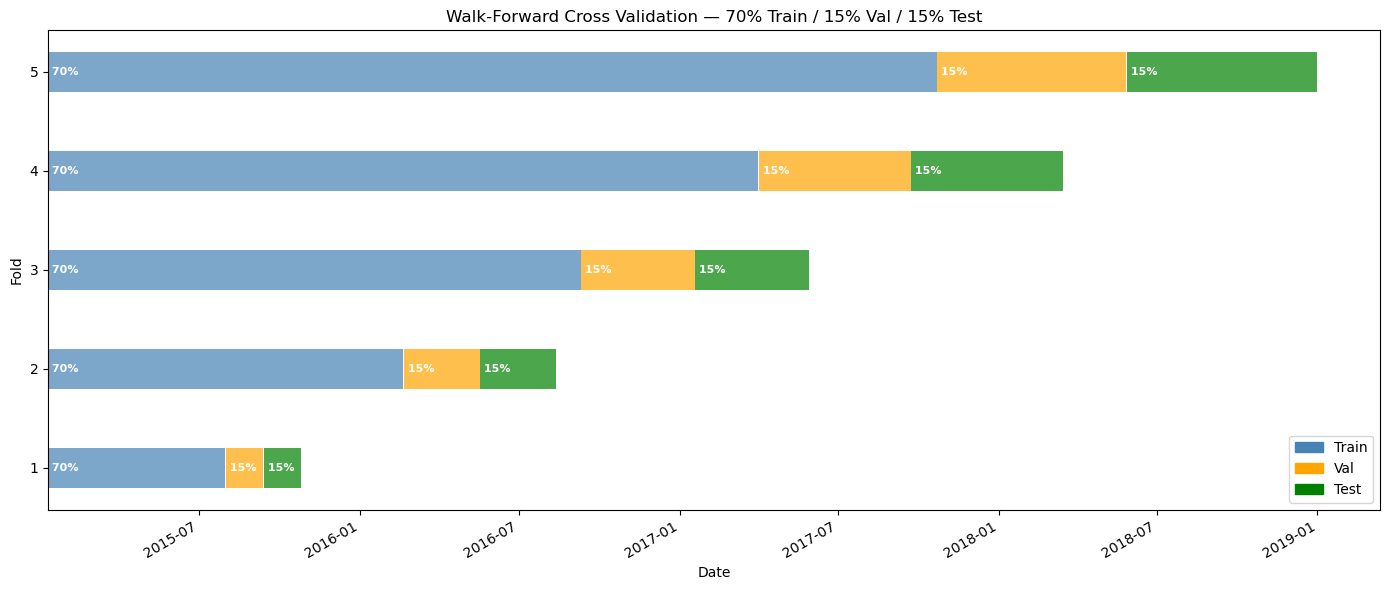

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = {'Train': 'steelblue', 'Val': 'orange', 'Test': 'green'}

for fold_data in folds:
    f = fold_data['fold']

    # Get time ranges from stored date arrays
    train_min = pd.Timestamp(fold_data['train_dates'].min())
    train_max = pd.Timestamp(fold_data['train_dates'].max())
    val_min   = pd.Timestamp(fold_data['val_dates'].min())
    val_max   = pd.Timestamp(fold_data['val_dates'].max())
    test_min  = pd.Timestamp(fold_data['test_dates'].min())
    test_max  = pd.Timestamp(fold_data['test_dates'].max())

    train_width = (train_max - train_min).days
    val_width   = (val_max   - val_min).days
    test_width  = (test_max  - test_min).days

    ax.barh(f, train_width, left=train_min,
            color='steelblue', alpha=0.7, height=0.4)
    ax.barh(f, val_width,   left=val_min,
            color='orange',   alpha=0.7, height=0.4)
    ax.barh(f, test_width,  left=test_min,
            color='green',    alpha=0.7, height=0.4)

    # Add percentage labels
    total = train_width + val_width + test_width
    ax.text(train_min, f, ' 70%', va='center',
            fontsize=8, color='white', fontweight='bold')
    ax.text(val_min,   f, ' 15%', va='center',
            fontsize=8, color='white', fontweight='bold')
    ax.text(test_min,  f, ' 15%', va='center',
            fontsize=8, color='white', fontweight='bold')

ax.xaxis_date()
fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Fold')
ax.set_title('Walk-Forward Cross Validation — 70% Train / 15% Val / 15% Test')

patches = [mpatches.Patch(color=c, label=l)
           for l, c in colors.items()]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.show()

In [27]:
# Check scaling for fold 5
fold_5 = folds[4]

print("===== FEATURE SCALING (X) =====")
print(f"\nX_train — Min: {fold_5['X_train'].min():.4f}  "
      f"Max: {fold_5['X_train'].max():.4f}")
print(f"X_val   — Min: {fold_5['X_val'].min():.4f}  "
      f"Max: {fold_5['X_val'].max():.4f}")
print(f"X_test  — Min: {fold_5['X_test'].min():.4f}  "
      f"Max: {fold_5['X_test'].max():.4f}")

print("\n===== TARGET SCALING (y) =====")
print(f"\n{'Target':<35} {'Train Min':>10} {'Train Max':>10} "
      f"{'Val Min':>10} {'Val Max':>10} "
      f"{'Test Min':>10} {'Test Max':>10}")
print("-" * 90)

for target in target_cols:
    y_tr = fold_5['y_train'][target]
    y_v  = fold_5['y_val'][target]
    y_te = fold_5['y_test'][target]

    print(f"{target:<35} "
          f"{y_tr.min():>10.4f} {y_tr.max():>10.4f} "
          f"{y_v.min():>10.4f}  {y_v.max():>10.4f} "
          f"{y_te.min():>10.4f} {y_te.max():>10.4f}")

print("\n===== PER FEATURE SCALING CHECK (X) =====")
print(f"\n{'Feature':<45} {'Train Min':>10} {'Train Max':>10}")
print("-" * 68)
for i, col in enumerate(feature_cols):
    print(f"{col:<45} "
          f"{fold_5['X_train'][:, i].min():>10.4f} "
          f"{fold_5['X_train'][:, i].max():>10.4f}")

===== FEATURE SCALING (X) =====

X_train — Min: -1.0000  Max: 1.0000
X_val   — Min: -1.0966  Max: 1.0386
X_test  — Min: -1.0000  Max: 1.0398

===== TARGET SCALING (y) =====

Target                               Train Min  Train Max    Val Min    Val Max   Test Min   Test Max
------------------------------------------------------------------------------------------
gen_solar                               0.0000     1.0000    -0.0016      1.0000    -0.0012     0.9602
gen_wind                                0.0000     1.0000    -0.0136      0.9202     0.0005     0.8589
total load actual                       0.0000     1.0000     0.0282      0.9588     0.0060     0.9860
price actual                            0.0000     1.0000     0.0129      1.0386     0.2747     0.7982
price day ahead                         0.0000     1.0000    -0.0024      0.8641     0.0070     0.7977

===== PER FEATURE SCALING CHECK (X) =====

Feature                                        Train Min  Train Max
------

In [37]:
import os
import torch

# ── Device ───────────────────────────────────────────────
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f"Using device : {device}")

if torch.cuda.is_available():
    print(f"GPU name     : {torch.cuda.get_device_name(0)}")
    print(f"GPU count    : {torch.cuda.device_count()}")

# ── Global settings ──────────────────────────────────────
WINDOW_SIZE  = 24
HORIZON      = 24
BATCH_SIZE   = 256 if torch.cuda.is_available() else 64
NUM_WORKERS  = 4   if torch.cuda.is_available() else 0
PIN_MEMORY   = torch.cuda.is_available()

# ── Model settings ───────────────────────────────────────
INPUT_SIZE   = folds[0]['X_train'].shape[1]
HIDDEN_SIZE  = 256
NUM_LAYERS   = 2
DROPOUT      = 0.3

print(f"\n── Settings ────────────────────────")
print(f"Window size  : {WINDOW_SIZE}")
print(f"Horizon      : {HORIZON}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Num workers  : {NUM_WORKERS}")
print(f"Pin memory   : {PIN_MEMORY}")
print(f"Input size   : {INPUT_SIZE}")
print(f"Hidden size  : {HIDDEN_SIZE}")
print(f"Num layers   : {NUM_LAYERS}")
print(f"Dropout      : {DROPOUT}")

Using device : cuda
GPU name     : NVIDIA RTX A4000
GPU count    : 1

── Settings ────────────────────────
Window size  : 24
Horizon      : 24
Batch size   : 256
Num workers  : 4
Pin memory   : True
Input size   : 55
Hidden size  : 256
Num layers   : 2
Dropout      : 0.3


In [38]:
class EnergyDataset(Dataset):
    def __init__(self, X, y,
                 window_size=24,
                 horizon=24):
        self.X           = torch.FloatTensor(X)
        self.y           = torch.FloatTensor(y).squeeze(-1)  # ← remove extra dim
        self.window_size = window_size
        self.horizon     = horizon

    def __len__(self):
        return len(self.X) - self.window_size - self.horizon + 1

    def __getitem__(self, idx):
        # Input: past window_size hours
        X_seq  = self.X[idx : idx + self.window_size]
        # shape: (24, 55)

        # Target 1: next 1 hour
        y_1hr  = self.y[idx + self.window_size].unsqueeze(-1)
        # shape: (1,)

        # Target 2: next 24 hours
        y_24hr = self.y[
            idx + self.window_size :
            idx + self.window_size + self.horizon
        ]
        # shape: (24,)

        return X_seq, y_1hr, y_24hr

In [39]:
# ── Updated DataLoader factory ───────────────────────────
def create_dataloaders(fold_data, target,
                       window_size=WINDOW_SIZE,
                       horizon=24,
                       batch_size=BATCH_SIZE,
                       num_workers=NUM_WORKERS,
                       pin_memory=PIN_MEMORY):

    train_dataset = EnergyDataset(
        fold_data['X_train'],
        fold_data['y_train'][target],
        window_size=window_size,
        horizon=horizon
    )
    val_dataset = EnergyDataset(
        fold_data['X_val'],
        fold_data['y_val'][target],
        window_size=window_size,
        horizon=horizon
    )
    test_dataset = EnergyDataset(
        fold_data['X_test'],
        fold_data['y_test'][target],
        window_size=window_size,
        horizon=horizon
    )

    # shared settings
    shared_kwargs = dict(
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0)
    )

    train_loader = DataLoader(
        train_dataset,
        drop_last=True,
        **shared_kwargs
    )
    val_loader = DataLoader(
        val_dataset,
        drop_last=False,
        **shared_kwargs
    )
    test_loader = DataLoader(
        test_dataset,
        drop_last=False,
        **shared_kwargs
    )

    return train_loader, val_loader, test_loader


# ── Recreate all dataloaders ─────────────────────────────
# Recreate with fixed dataset
all_dataloaders = {}

for fold_data in folds:
    fold_num = fold_data['fold']
    all_dataloaders[fold_num] = {}

    for target in target_cols:
        train_loader, val_loader, test_loader = \
            create_dataloaders(fold_data, target)

        all_dataloaders[fold_num][target] = {
            'train': train_loader,
            'val'  : val_loader,
            'test' : test_loader
        }
    print(f"Fold {fold_num} dataloaders recreated ")

# Verify shapes
fold_5_loaders = all_dataloaders[5]
X_batch, y_1hr, y_24hr = next(
    iter(fold_5_loaders[target_cols[0]]['train']))

print(f"X_batch : {tuple(X_batch.shape)}")
print(f"y_1hr   : {tuple(y_1hr.shape)}")
print(f"y_24hr  : {tuple(y_24hr.shape)}")
# Expected:
# X_batch : (256, 24, 55)
# y_1hr   : (256, 1)
# y_24hr  : (256, 24)


# ── Verify new shapes ────────────────────────────────────
print("\n===== VERIFICATION (Fold 5) =====")
for target in target_cols:
    loaders = all_dataloaders[5][target]

    # unpack 3 values now instead of 2
    X_batch, y_1hr, y_24hr = next(iter(loaders['train']))

    print(f"\n{target}:")
    print(f"  Train batches  : {len(loaders['train']):>6,}")
    print(f"  Val   batches  : {len(loaders['val']):>6,}")
    print(f"  Test  batches  : {len(loaders['test']):>6,}")
    print(f"  X shape        : {tuple(X_batch.shape)}"
          f"  → (batch, window, features)")
    print(f"  y_1hr shape    : {tuple(y_1hr.shape)}"
          f"  → (batch, 1)")
    print(f"  y_24hr shape   : {tuple(y_24hr.shape)}"
          f"  → (batch, 24)")

Fold 1 dataloaders recreated 
Fold 2 dataloaders recreated 
Fold 3 dataloaders recreated 
Fold 4 dataloaders recreated 
Fold 5 dataloaders recreated 
X_batch : (256, 24, 55)
y_1hr   : (256, 1)
y_24hr  : (256, 24)

===== VERIFICATION (Fold 5) =====

generation solar:
  Train batches  :    487
  Val   batches  :    105
  Test  batches  :    105
  X shape        : (256, 24, 55)  → (batch, window, features)
  y_1hr shape    : (256, 1)  → (batch, 1)
  y_24hr shape   : (256, 24)  → (batch, 24)

generation wind onshore:
  Train batches  :    487
  Val   batches  :    105
  Test  batches  :    105
  X shape        : (256, 24, 55)  → (batch, window, features)
  y_1hr shape    : (256, 1)  → (batch, 1)
  y_24hr shape   : (256, 24)  → (batch, 24)

total load actual:
  Train batches  :    487
  Val   batches  :    105
  Test  batches  :    105
  X shape        : (256, 24, 55)  → (batch, window, features)
  y_1hr shape    : (256, 1)  → (batch, 1)
  y_24hr shape   : (256, 24)  → (batch, 24)

price ac

In [ ]:
import torch.nn.functional as F


# ── 1. Attention Layer ───────────────────────────────────
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super(AttentionLayer, self).__init__()
        # learns importance score for each timestep
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, gru_output):
        # gru_output: (batch, window, hidden_size)

        # compute score for each timestep
        scores = self.attention(gru_output)  # (batch, window, 1)
        scores = scores.squeeze(-1)           # (batch, window)

        # convert scores to probabilities
        weights = F.softmax(scores, dim=1)    # (batch, window)

        # weighted sum of all hidden states
        weights  = weights.unsqueeze(-1)       # (batch, window, 1)
        context  = torch.sum(gru_output * weights, dim=1)      # (batch, hidden_size)

        return context, weights.squeeze(-1)
    
# ── 2. CNN Encoder ───────────────────────────────────
class CNNEncoder(nn.Module):
    def __init__(self, input_size, cnn_channels=(32, 128, 128)):

        super(CNNEncoder, self).__init__()
        # Conv1d operates on (batch, channels, seq_len)
        # input_size (features) = in_channels for the first layer

        self.out_channels = cnn_channels[-1]

        self.features = nn.Sequential(
            # CONV1, kernel=3, filters=32
            nn.Conv1d(in_channels=input_size, out_channels=cnn_channels[0], kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),

            # CONV2, kernel=5, filters=128
            # Increase padding in order to preserve sequence length between convolution layers
            nn.Conv1d(in_channels=cnn_channels[0], out_channels=cnn_channels[1], kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),

            # CONV3, kernel=7, filters=128
            # Increase padding in order to preserve sequence length between convolution layers
            nn.Conv1d(in_channels=cnn_channels[1], out_channels=cnn_channels[2], kernel_size=7, stride=1, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x):
        # x in:  (batch, seq_len, input_size)  — standard time-series format
        x = x.permute(0, 2, 1)      # → (batch, input_size,  seq_len) for Conv1d
        x = self.features(x)        # → (batch, 128, seq_len)
        x = x.permute(0, 2, 1)      # → (batch, seq_len, 128)    for GRU
        return x

# ── 3. Decoder for 24hr ahead ────────────────────────────
class Decoder(nn.Module):
    def __init__(self, hidden_size, output_steps=24):
        super(Decoder, self).__init__()
        self.output_steps = output_steps
        self.gru          = nn.GRU(
            input_size=1,           # takes previous prediction as input
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, context):
        # context: (batch, hidden_size)
        # expand context to use as initial hidden state
        h0  = context.unsqueeze(0)             # (1, batch, hidden_size)

        # start token — zeros
        batch_size = context.size(0)
        decoder_input = torch.zeros(
            batch_size, 1, 1).to(context.device) # (batch, 1, 1)

        predictions = []

        # generate one prediction at a time
        for _ in range(self.output_steps):
            out, h0  = self.gru(
                decoder_input, h0)         # (batch, 1, hidden)
            pred           = self.fc(
                out.squeeze(1))                   # (batch, 1)
            predictions.append(pred)
            decoder_input  = pred.unsqueeze(1)   # feed prediction back in

        # stack all 24 predictions
        predictions = torch.cat(predictions, dim=1)  # (batch, 24)
        return predictions


# ── 3. Full Model ────────────────────────────────────────
class EnergyForecastModel(nn.Module):
    def __init__(self,
                 input_size,        # 55 features
                 cnn_channels=(32, 128, 128),       # tunable input parameters
                 hidden_size=256,
                 dropout=0.3):
        super(EnergyForecastModel, self).__init__()

        self.hidden_size = hidden_size

        # ── CNN Encoder ──────────────────────────────
        # Takes raw (batch, seq_len, input_size) → (batch, seq_len, 128)
        self.cnn = CNNEncoder(input_size=input_size, cnn_channels=cnn_channels)

        # ── GRU Stack ──────────────────────────────
        self.gru = nn.GRU(
            input_size=self.cnn.out_channels,
            hidden_size=hidden_size,
            num_layers=3,
            dropout=dropout,
            batch_first=True,
        )

        # ── Dropout ──────────────────────────────────────
        self.dropout = nn.Dropout(dropout)

        # ── Attention ────────────────────────────────────
        self.attention = AttentionLayer(hidden_size * 2)

        # ── Dense Head (paper's ReLU → Dense 512) ────────
        # Used as a shared projection before both output heads
        self.dense = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── Head 1: 1hr ahead ────────────────────────────
        self.fc_1hr = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

        # ── Head 2: 24hr Decoder ─────────────────────────
        self.decoder_24hr = Decoder(
            hidden_size=hidden_size * 2,
            output_steps=24
        )

    def forward(self, x):

        # x: (batch, seq_len, input_size)

        # ── CNN feature extraction ────────────────────────
        x = self.cnn(x)               # (batch, seq_len, 128)

        # ── GRU sequence modelling ────────────────────────
        gru_out, _ = self.gru(x)      # (batch, seq_len, 128)
        gru_out    = self.dropout(gru_out)

        # ── Attention pooling ─────────────────────────────
        context, attn_weights = self.attention(gru_out)
        # context: (batch, 128)

        # ── Shared dense projection ───────────────────────
        context = self.dense(context) # (batch, 512)

        # ── Output heads ──────────────────────────────────
        pred_1hr  = self.fc_1hr(context)       # (batch, 1)
        pred_24hr = self.decoder_24hr(context) # (batch, 24)

        return pred_1hr, pred_24hr, attn_weights

In [41]:
 
# Instantiate model
INPUT_SIZE  = folds[0]['X_train'].shape[1]  # 55 features
HIDDEN_SIZE = 256
NUM_LAYERS  = 2
DROPOUT     = 0.3
# OUTPUT_SIZE = 1

model = EnergyForecastModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

print(model)
print(f"\nInput size  : {INPUT_SIZE}")
print(f"Hidden size : {HIDDEN_SIZE}")
print(f"Num layers  : {NUM_LAYERS}")
print(f"Bidirectional — FC input: {HIDDEN_SIZE * 2}")

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() 
                   if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")


EnergyForecastModel(
  (encoder): LSTM(55, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=512, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_1hr): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
  (decoder_24hr): Decoder(
    (lstm): LSTM(1, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=1, bias=True)
  )
)

Input size  : 55
Hidden size : 256
Num layers  : 2
Bidirectional — FC input: 512

Trainable parameters: 3,339,523


In [42]:
from tqdm import tqdm
import copy

# ── 1. Custom Loss ───────────────────────────────────────
class CustomLoss(nn.Module):
    def __init__(self, alpha=0.1, beta=0.01):
        super(CustomLoss, self).__init__()
        self.alpha = alpha
        self.beta  = beta

    def forward(self, y_pred, y_true):
        # Ensure same shape
        y_pred = y_pred.squeeze()
        y_true = y_true.squeeze()

        # ── MAE ─────────────────────────────────────────
        mae = torch.mean(torch.abs(y_true - y_pred))

        # ── JSD ─────────────────────────────────────────
        y_true_soft = torch.softmax(y_true, dim=0)
        y_pred_soft = torch.softmax(y_pred, dim=0)
        m           = 0.5 * (y_true_soft + y_pred_soft)
        kl1         = torch.sum(
            y_true_soft * torch.log(y_true_soft / (m + 1e-8) + 1e-8))
        kl2         = torch.sum(
            y_pred_soft * torch.log(y_pred_soft / (m + 1e-8) + 1e-8))
        jsd         = 0.5 * (kl1 + kl2)

        # ── Smoothness ───────────────────────────────────
        smoothness  = torch.mean((y_pred[1:] - y_pred[:-1]) ** 2)

        return mae + self.alpha * jsd + self.beta * smoothness



In [43]:
# 2. Device 
device = torch.device(
    'mps'  if torch.backends.mps.is_available() else  # Mac GPU
    'cuda' if torch.cuda.is_available()          else  # NVIDIA GPU
    'cpu'                                              # CPU fallback
)
print(f"Using device: {device}")

Using device: cuda


In [44]:
def train_model(model, train_loader, val_loader,
                num_epochs=50, lr=0.001,
                loss_fn='mae',
                alpha=0.1,
                beta=0.01):

    model = model.to(device)

    # ── Loss selection ───────────────────────────────────
    if loss_fn == 'mae':
        criterion = nn.L1Loss()
        print(f"Loss: MAE")
    elif loss_fn == 'mse':
        criterion = nn.MSELoss()
        print(f"Loss: MSE")
    elif loss_fn == 'custom':
        criterion = CustomLoss(alpha=alpha, beta=beta)
        print(f"Loss: Custom α={alpha} β={beta}")
    else:
        raise ValueError("loss_fn must be 'mae', 'mse' or 'custom'")

    # ── Optimizer ────────────────────────────────────────
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr)

    # ── Scheduler ────────────────────────────────────────
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=5,
        factor=0.5
        # removed verbose=True — deprecated
    )

    # ── Tracking ─────────────────────────────────────────
    best_val_loss = float('inf')
    best_weights  = copy.deepcopy(model.state_dict())
    history       = {
        'train_loss': [],
        'val_loss'  : [],
        'lr'        : []
    }

    for epoch in range(num_epochs):

        # ══════════════════════════════════════════════
        # TRAINING
        # ══════════════════════════════════════════════
        model.train()
        train_losses = []

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1:>3}/{num_epochs} [Train]",
            leave=False
        )

        # Add squeeze/unsqueeze fixes in training loop
        for X_batch, y_1hr, y_24hr in train_bar:
            X_batch = X_batch.to(device)
            y_1hr   = y_1hr.to(device)             # (batch, 1)
            y_24hr  = y_24hr.to(device)            # (batch, 24)
        
            pred_1hr, pred_24hr, _ = model(X_batch)
            # pred_1hr  : (batch, 1)
            # pred_24hr : (batch, 24)
        
            loss_1hr  = criterion(pred_1hr,  y_1hr)    # (64,1)  vs (64,1)  
            loss_24hr = criterion(pred_24hr, y_24hr)   # (64,24) vs (64,24) 
            loss      = 0.7 * loss_1hr + 0.3 * loss_24hr

            # skip NaN
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"  ⚠️  NaN/Inf — skipping batch")
                continue

            # backward pass
            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0)

            optimizer.step()
            train_losses.append(loss.item())

            train_bar.set_postfix({
                '1hr' : f"{loss_1hr.item():.4f}",
                '24hr': f"{loss_24hr.item():.4f}",
                'avg' : f"{np.mean(train_losses):.4f}"
            })

        avg_train_loss = np.mean(train_losses) \
                         if train_losses else float('nan')

        # ══════════════════════════════════════════════
        # VALIDATION
        # ══════════════════════════════════════════════
        model.eval()
        val_losses      = []
        val_losses_1hr  = []
        val_losses_24hr = []

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1:>3}/{num_epochs} [Val]  ",
            leave=False
        )

        with torch.no_grad():
            for X_batch, y_1hr, y_24hr in val_bar:

                X_batch = X_batch.to(device)
                y_1hr   = y_1hr.to(device)
                y_24hr  = y_24hr.to(device)

                pred_1hr, pred_24hr, _ = model(X_batch)

                loss_1hr  = criterion(pred_1hr,  y_1hr)
                loss_24hr = criterion(pred_24hr, y_24hr)
                loss      = 0.7 * loss_1hr + \
                            0.3 * loss_24hr

                if torch.isnan(loss) or \
                   torch.isinf(loss):
                    continue

                val_losses.append(loss.item())
                val_losses_1hr.append(loss_1hr.item())
                val_losses_24hr.append(loss_24hr.item())

                val_bar.set_postfix({
                    '1hr' : f"{loss_1hr.item():.4f}",
                    '24hr': f"{loss_24hr.item():.4f}",
                    'avg' : f"{np.mean(val_losses):.4f}"
                })

        avg_val_loss    = np.mean(val_losses) \
                          if val_losses else float('nan')
        avg_val_1hr     = np.mean(val_losses_1hr) \
                          if val_losses_1hr else float('nan')
        avg_val_24hr    = np.mean(val_losses_24hr) \
                          if val_losses_24hr else float('nan')

        # ── Save best model ───────────────────────────
        if not np.isnan(avg_val_loss) and \
               avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights  = copy.deepcopy(
                model.state_dict())
            print(f"  ✅ Epoch {epoch+1:>3} — "
                  f"best model saved "
                  f"val={best_val_loss:.4f}")

        # ── Scheduler step ────────────────────────────
        if not np.isnan(avg_val_loss):
            scheduler.step(avg_val_loss)

        # ── Store history ─────────────────────────────
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['lr'].append(
            optimizer.param_groups[0]['lr'])

        # ── Epoch summary ─────────────────────────────
        print(f"Epoch {epoch+1:>3}/{num_epochs} | "
              f"Train: {avg_train_loss:.4f} | "
              f"Val: {avg_val_loss:.4f} | "
              f"Val 1hr: {avg_val_1hr:.4f} | "
              f"Val 24hr: {avg_val_24hr:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # ── Load best weights ─────────────────────────────
    model.load_state_dict(best_weights)
    print(f"\n✅ Training complete — "
          f"best val loss: {best_val_loss:.4f}")
    return model, history

In [ ]:
def test_model(model, test_loader, target_scaler):
    model.eval()
    criterion = nn.L1Loss()

    all_preds_1hr  = []
    all_preds_24hr = []
    all_actuals_1hr  = []
    all_actuals_24hr = []
    test_losses    = []

    test_bar = tqdm(
        test_loader,
        desc="Testing",
        leave=True
    )

    with torch.no_grad():
        # ── unpack 3 values ───────────────────────────
        for X_batch, y_1hr, y_24hr in test_bar:

            X_batch = X_batch.to(device)
            y_1hr   = y_1hr.to(device)
            y_24hr  = y_24hr.to(device)

            # forward pass
            pred_1hr, pred_24hr, _ = model(X_batch)

            # compute loss on 1hr prediction
            loss_1hr  = criterion(pred_1hr,  y_1hr)
            loss_24hr = criterion(pred_24hr, y_24hr)
            loss      = 0.7 * loss_1hr + 0.3 * loss_24hr

            test_losses.append(loss.item())

            # store predictions and actuals
            all_preds_1hr.append(
                pred_1hr.cpu().numpy())
            all_preds_24hr.append(
                pred_24hr.cpu().numpy())
            all_actuals_1hr.append(
                y_1hr.cpu().numpy())
            all_actuals_24hr.append(
                y_24hr.cpu().numpy())

            test_bar.set_postfix({
                '1hr' : f"{loss_1hr.item():.4f}",
                '24hr': f"{loss_24hr.item():.4f}",
                'avg' : f"{np.mean(test_losses):.4f}"
            })

    # ── Concatenate all batches ───────────────────────
    all_preds_1hr    = np.concatenate(
        all_preds_1hr,    axis=0)
    all_preds_24hr   = np.concatenate(
        all_preds_24hr,   axis=0)
    all_actuals_1hr  = np.concatenate(
        all_actuals_1hr,  axis=0)
    all_actuals_24hr = np.concatenate(
        all_actuals_24hr, axis=0)

    # ── Inverse transform 1hr ────────────────────────
    preds_1hr_orig   = target_scaler.inverse_transform(
        all_preds_1hr.reshape(-1, 1))
    actuals_1hr_orig = target_scaler.inverse_transform(
        all_actuals_1hr.reshape(-1, 1))

    # ── Inverse transform 24hr ───────────────────────
    # reshape to (-1, 1) to inverse transform
    # then reshape back to (-1, 24)
    n_samples        = all_preds_24hr.shape[0]

    preds_24hr_orig  = target_scaler.inverse_transform(
        all_preds_24hr.reshape(-1, 1)
    ).reshape(n_samples, 24)

    actuals_24hr_orig = target_scaler.inverse_transform(
        all_actuals_24hr.reshape(-1, 1)
    ).reshape(n_samples, 24)

    # ── Compute test-set range from actual 1hr values ─
    # Range = max - min of the inverse-transformed test actuals.
    # Using 1hr actuals (same underlying series as 24hr, just
    # differently windowed) as the canonical range reference.
    actual_min   = float(actuals_1hr_orig.min())
    actual_max   = float(actuals_1hr_orig.max())
    actual_range = actual_max - actual_min  # avoids division by near-zero

    # ── Metrics on 1hr prediction ────────────────────
    mae_1hr  = np.mean(
        np.abs(actuals_1hr_orig - preds_1hr_orig))
    mse_1hr  = np.mean(
        (actuals_1hr_orig - preds_1hr_orig) ** 2)
    rmse_1hr = np.sqrt(mse_1hr)

    # ── Metrics on 24hr prediction ───────────────────
    mae_24hr  = np.mean(
        np.abs(actuals_24hr_orig - preds_24hr_orig))
    mse_24hr  = np.mean(
        (actuals_24hr_orig - preds_24hr_orig) ** 2)
    rmse_24hr = np.sqrt(mse_24hr)

    # ── Percentage errors using actual test range ─────
    mae_pct_1hr  = (mae_1hr  / actual_range) * 100
    mae_pct_24hr = (mae_24hr / actual_range) * 100

    # ── Print results ────────────────────────────────
    print(f"\n===== TEST RESULTS =====")
    print(f"\n  1hr  Prediction:")
    print(f"    MAE  : {mae_1hr:.4f}")
    print(f"    MSE  : {mse_1hr:.4f}")
    print(f"    RMSE : {rmse_1hr:.4f}")
    print(f"\n  24hr Prediction:")
    print(f"    MAE  : {mae_24hr:.4f}")
    print(f"    MSE  : {mse_24hr:.4f}")
    print(f"    RMSE : {rmse_24hr:.4f}")

    return (
        preds_1hr_orig,
        preds_24hr_orig,
        actuals_1hr_orig,
        actuals_24hr_orig,
        {
            '1hr' : {
                'mae' : mae_1hr,
                'mse' : mse_1hr,
                'rmse': rmse_1hr,
                'mae_pct': mae_pct_1hr
            },
            '24hr': {
                'mae' : mae_24hr,
                'mse' : mse_24hr,
                'rmse': rmse_24hr,
                'mae_pct': mae_pct_24hr
            },
            'test_range': {
                'min'  : actual_min,
                'max'  : actual_max,
                'range': actual_range,
            }
        }
    )

In [46]:
# ── Train all targets on Fold 5 ──────────────────────────
fold_5         = folds[4]
fold_5_loaders = all_dataloaders[5]

trained_models = {}
all_history    = {}
all_results    = {}

for target in target_cols:
    print(f"\n{'='*55}")
    print(f"Training: {target}")
    print(f"{'='*55}")

    model = EnergyForecastModel(
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    )

    trained_model, history = train_model(
        model,
        fold_5_loaders[target]['train'],
        fold_5_loaders[target]['val'],
        num_epochs=50,
        lr=0.001,
        loss_fn='mae'
    )

    # ── fix: unpack 5 values ─────────────────────────
    preds_1hr, preds_24hr, \
    actuals_1hr, actuals_24hr, metrics = test_model(
        trained_model,
        fold_5_loaders[target]['test'],
        fold_5['target_scalers'][target]
    )

    trained_models[target] = trained_model
    all_history[target]    = history
    all_results[target]    = {
        'preds_1hr'   : preds_1hr,
        'preds_24hr'  : preds_24hr,
        'actuals_1hr' : actuals_1hr,
        'actuals_24hr': actuals_24hr,
        'metrics'     : metrics
    }

# ── Summary ──────────────────────────────────────────────
print(f"\n{'='*85}")
print(f"FINAL RESULTS — FOLD 5")
print(f"{'='*85}")
print(f"\n{'Target':<30} {'1hr MAE':>9} {'1hr RMSE':>10} "
      f"{'24hr MAE':>10} {'24hr RMSE':>11}")
print("-" * 65)

for target in target_cols:
    m = all_results[target]['metrics']
    print(f"{target:<30} "
          f"{m['1hr']['mae']:>9.4f} "
          f"{m['1hr']['rmse']:>10.4f} "
          f"{m['24hr']['mae']:>10.4f} "
          f"{m['24hr']['rmse']:>11.4f}")


Training: generation solar
Loss: MAE


  ✅ Epoch   1 — best model saved val=0.0462
Epoch   1/50 | Train: 0.0952 | Val: 0.0462 | Val 1hr: 0.0353 | Val 24hr: 0.0717 | LR: 0.001000


  ✅ Epoch   2 — best model saved val=0.0418
Epoch   2/50 | Train: 0.0508 | Val: 0.0418 | Val 1hr: 0.0319 | Val 24hr: 0.0648 | LR: 0.001000


  ✅ Epoch   3 — best model saved val=0.0405
Epoch   3/50 | Train: 0.0460 | Val: 0.0405 | Val 1hr: 0.0285 | Val 24hr: 0.0686 | LR: 0.001000


  ✅ Epoch   4 — best model saved val=0.0351
Epoch   4/50 | Train: 0.0418 | Val: 0.0351 | Val 1hr: 0.0237 | Val 24hr: 0.0617 | LR: 0.001000


...

Epoch  48/50 | Train: 0.0200 | Val: 0.0211 | Val 1hr: 0.0147 | Val 24hr: 0.0360 | LR: 0.000500


Epoch  49/50 | Train: 0.0197 | Val: 0.0202 | Val 1hr: 0.0135 | Val 24hr: 0.0359 | LR: 0.000250


Epoch  50/50 | Train: 0.0197 | Val: 0.0213 | Val 1hr: 0.0149 | Val 24hr: 0.0363 | LR: 0.000250

✅ Training complete — best val loss: 0.0191


Testing: 100%|██████████| 105/105 [00:01<00:00, 55.92it/s, 1hr=0.0101, 24hr=0.0366, avg=0.0210]



===== TEST RESULTS =====

  1hr  Prediction:
    MAE  : 1.3386
    MSE  : 3.8669
    RMSE : 1.9664

  24hr Prediction:
    MAE  : 3.8683
    MSE  : 27.3232
    RMSE : 5.2272

FINAL RESULTS — FOLD 5

Target                           1hr MAE   1hr RMSE   24hr MAE   24hr RMSE
-----------------------------------------------------------------
generation solar                 60.0939   103.9711   201.7285    369.7210
generation wind onshore         136.0577   331.8605   598.0402    985.5243
total load actual               248.2548   370.9312   788.6513   1117.0752
price actual                      1.3343     1.7761     3.4454      4.4692
price day ahead                   1.3386     1.9664     3.8683      5.2272


In [ ]:
# ── Summary ──────────────────────────────────────────────
print(f"\n{'='*95}")
print(f"FINAL RESULTS — FOLD 5")
print(f"{'='*95}")
print(f"\n{'Target':<30} {'Range':>12} {'1hr MAE':>9} {'1hr MAE%':>9} "
      f"{'1hr RMSE':>10} {'24hr MAE':>10} {'24hr MAE%':>10} {'24hr RMSE':>11}")
print("-" * 95)

for target in target_cols:
    m = all_results[target]['metrics']
    r = m['test_range']
    print(f"{target:<30} "
          f"{r['range']:>12.2f} "
          f"{m['1hr']['mae']:>9.4f} "
          f"{m['1hr']['mae_pct']:>8.1f}% "
          f"{m['1hr']['rmse']:>10.4f} "
          f"{m['24hr']['mae']:>10.4f} "
          f"{m['24hr']['mae_pct']:>9.1f}% "
          f"{m['24hr']['rmse']:>11.4f}")

In [ ]:
# # ── Summary ──────────────────────────────────────────────
# print(f"\n{'='*85}")
# print(f"FINAL RESULTS — FOLD 5")
# print(f"{'='*85}")
# print(f"\n{'Target':<30} {'1hr MAE':>9} {'1hr RMSE':>10} "
#       f"{'24hr MAE':>10} {'24hr RMSE':>11}")
# print("-" * 75)

# for target in target_cols:
#     m = all_results[target]['metrics']
#     print(f"{target:<30} "
#           f"{m['1hr']['mae']:>9.4f} "
#           f"{m['1hr']['rmse']:>10.4f} "
#           f"{m['24hr']['mae']:>10.4f} "
#           f"{m['24hr']['rmse']:>11.4f}")


FINAL RESULTS — FOLD 5

Target                           1hr MAE   1hr RMSE   24hr MAE   24hr RMSE
---------------------------------------------------------------------------
generation solar                 60.0939   103.9711   201.7285    369.7210
generation wind onshore         136.0577   331.8605   598.0402    985.5243
total load actual               248.2548   370.9312   788.6513   1117.0752
price actual                      1.3343     1.7761     3.4454      4.4692
price day ahead                   1.3386     1.9664     3.8683      5.2272



TEST RESULTS — FOLD 5

Target                           1hr MAE   1hr RMSE   24hr MAE   24hr RMSE    MAE% Status
-------------------------------------------------------------------------------------
generation solar                   60.09     103.97     201.73      369.72    1.0%   ✅ Good
generation wind onshore           136.06     331.86     598.04      985.52    0.8%   ✅ Good
total load actual                 248.25     370.93     788.65     1117.08    1.1%   ✅ Good
price actual                        1.33       1.78       3.45        4.47    1.2%   ✅ Good
price day ahead                     1.34       1.97       3.87        5.23    1.3%   ✅ Good


/tmp/ipykernel_3411102/2370636391.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


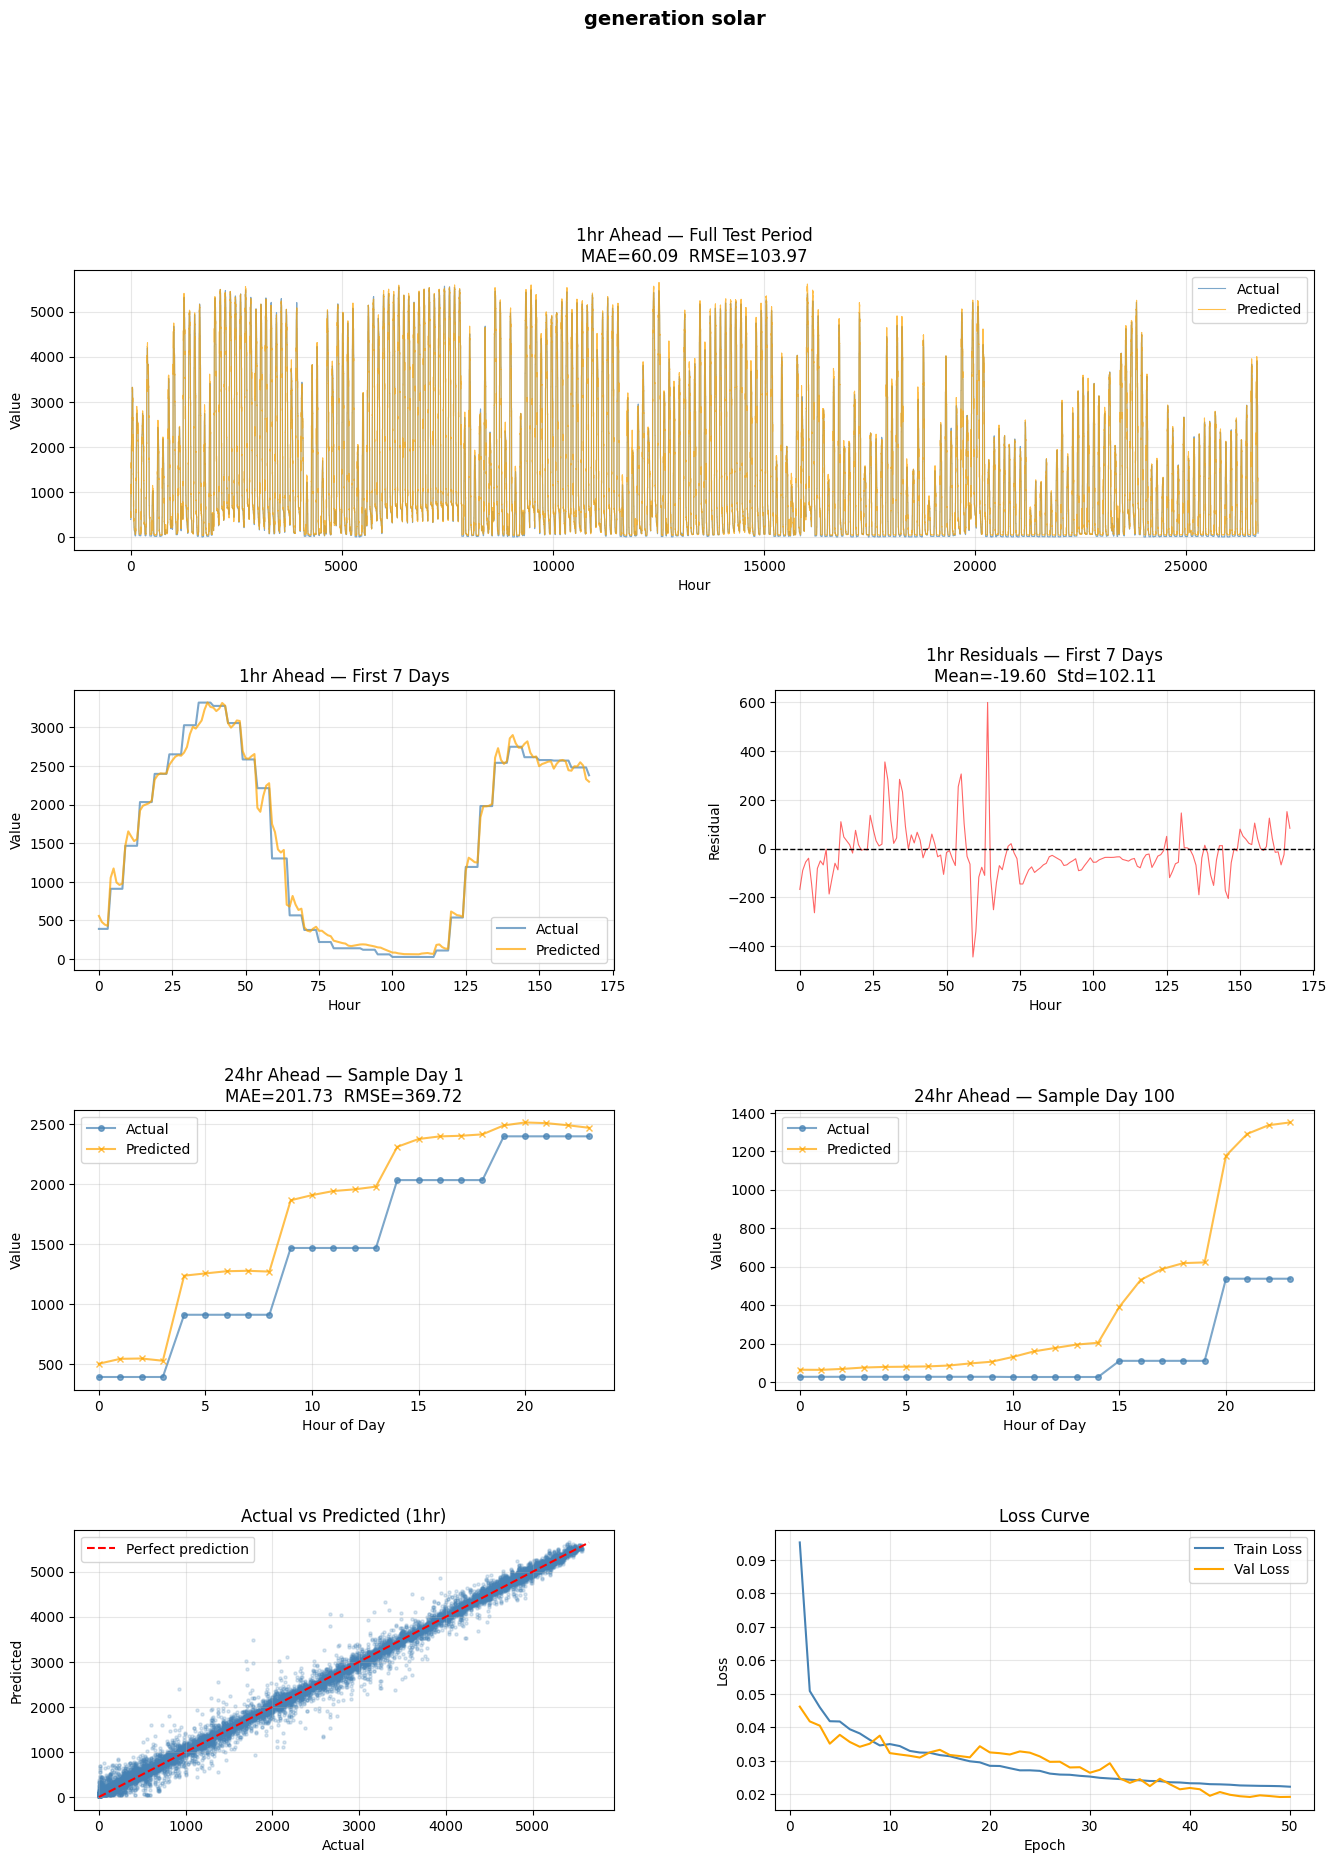

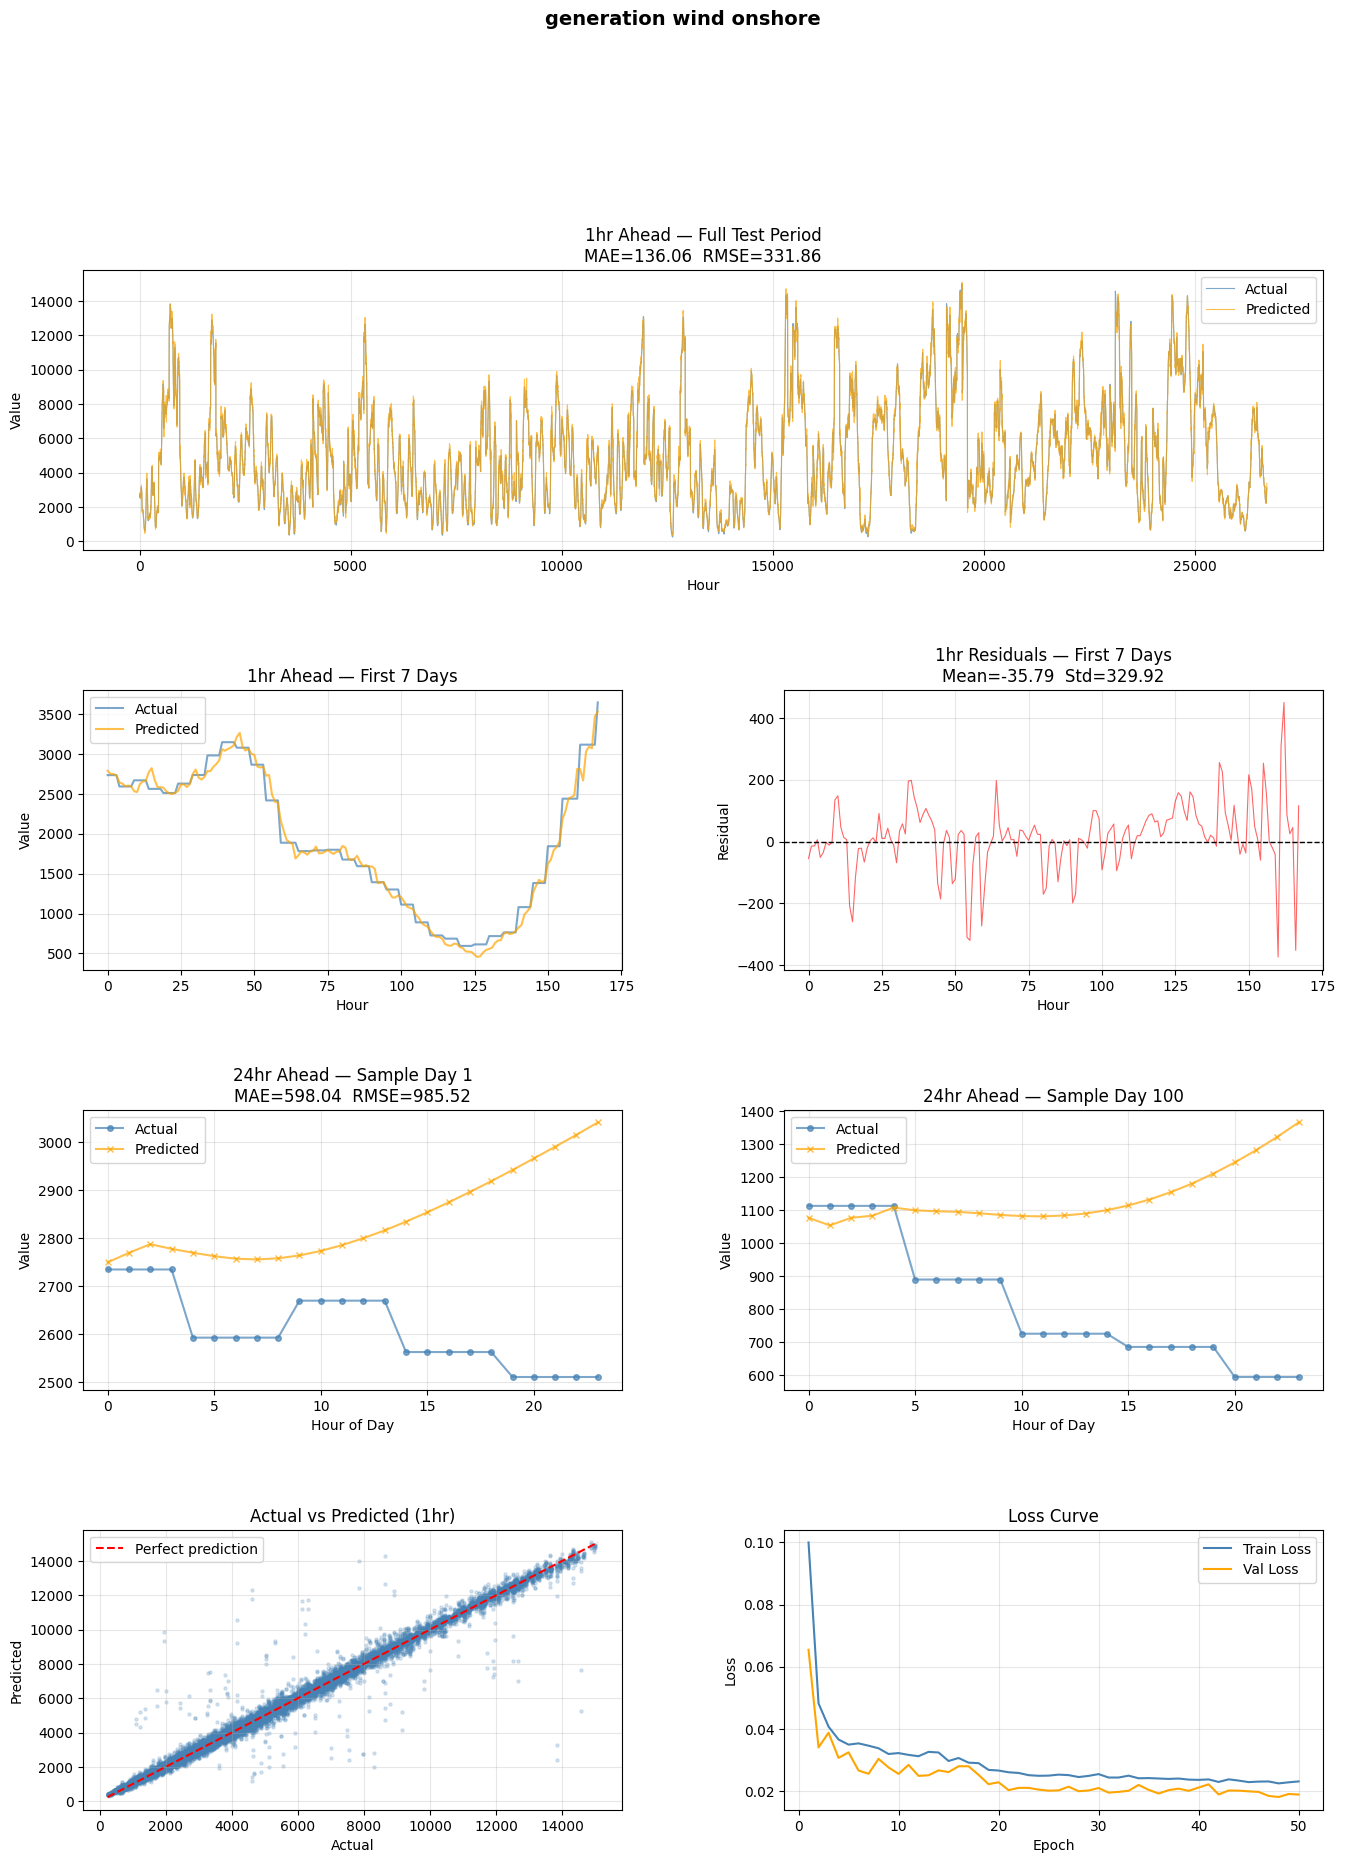

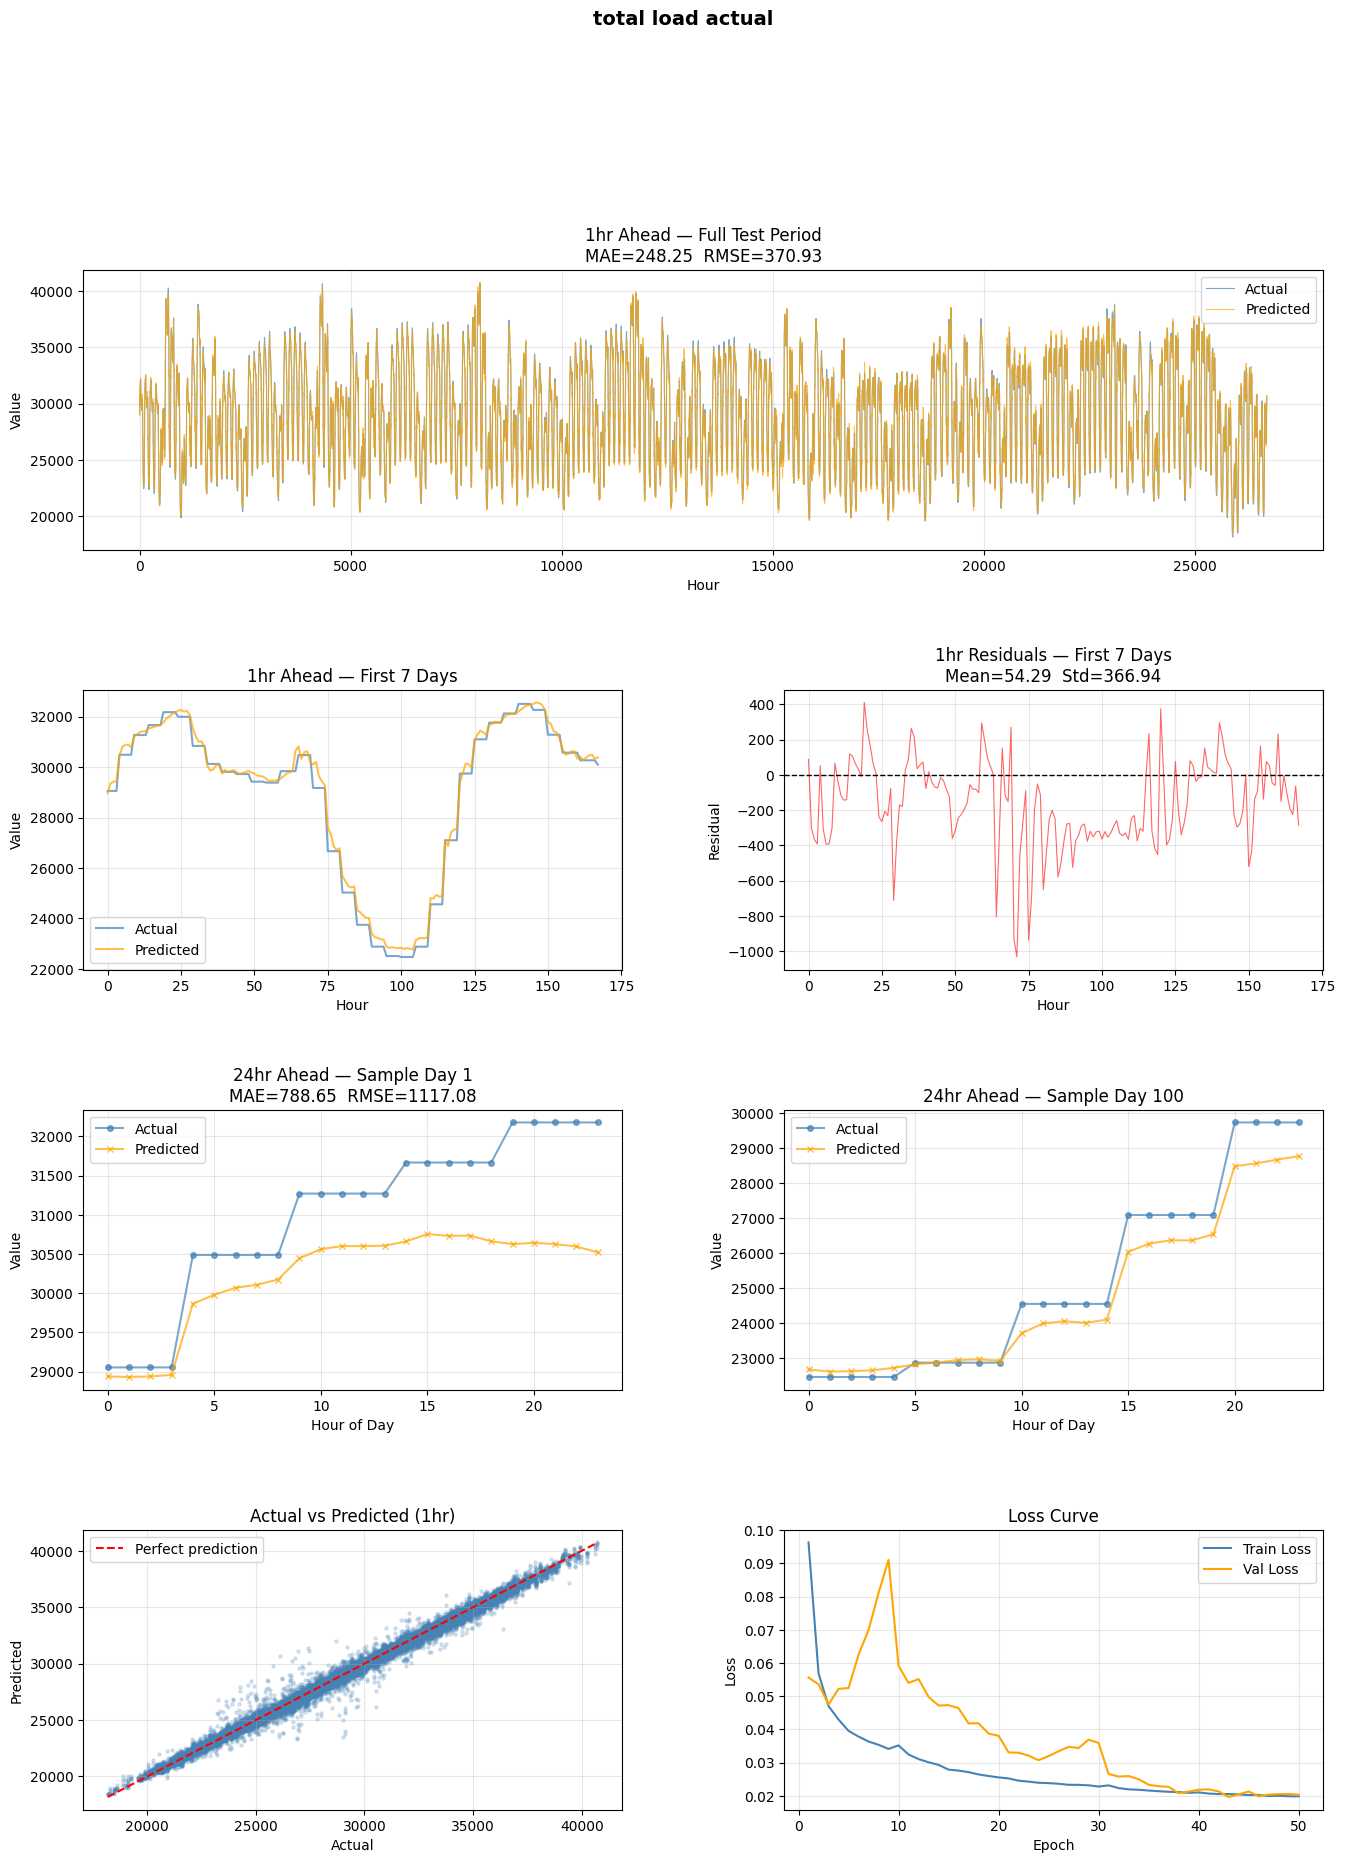

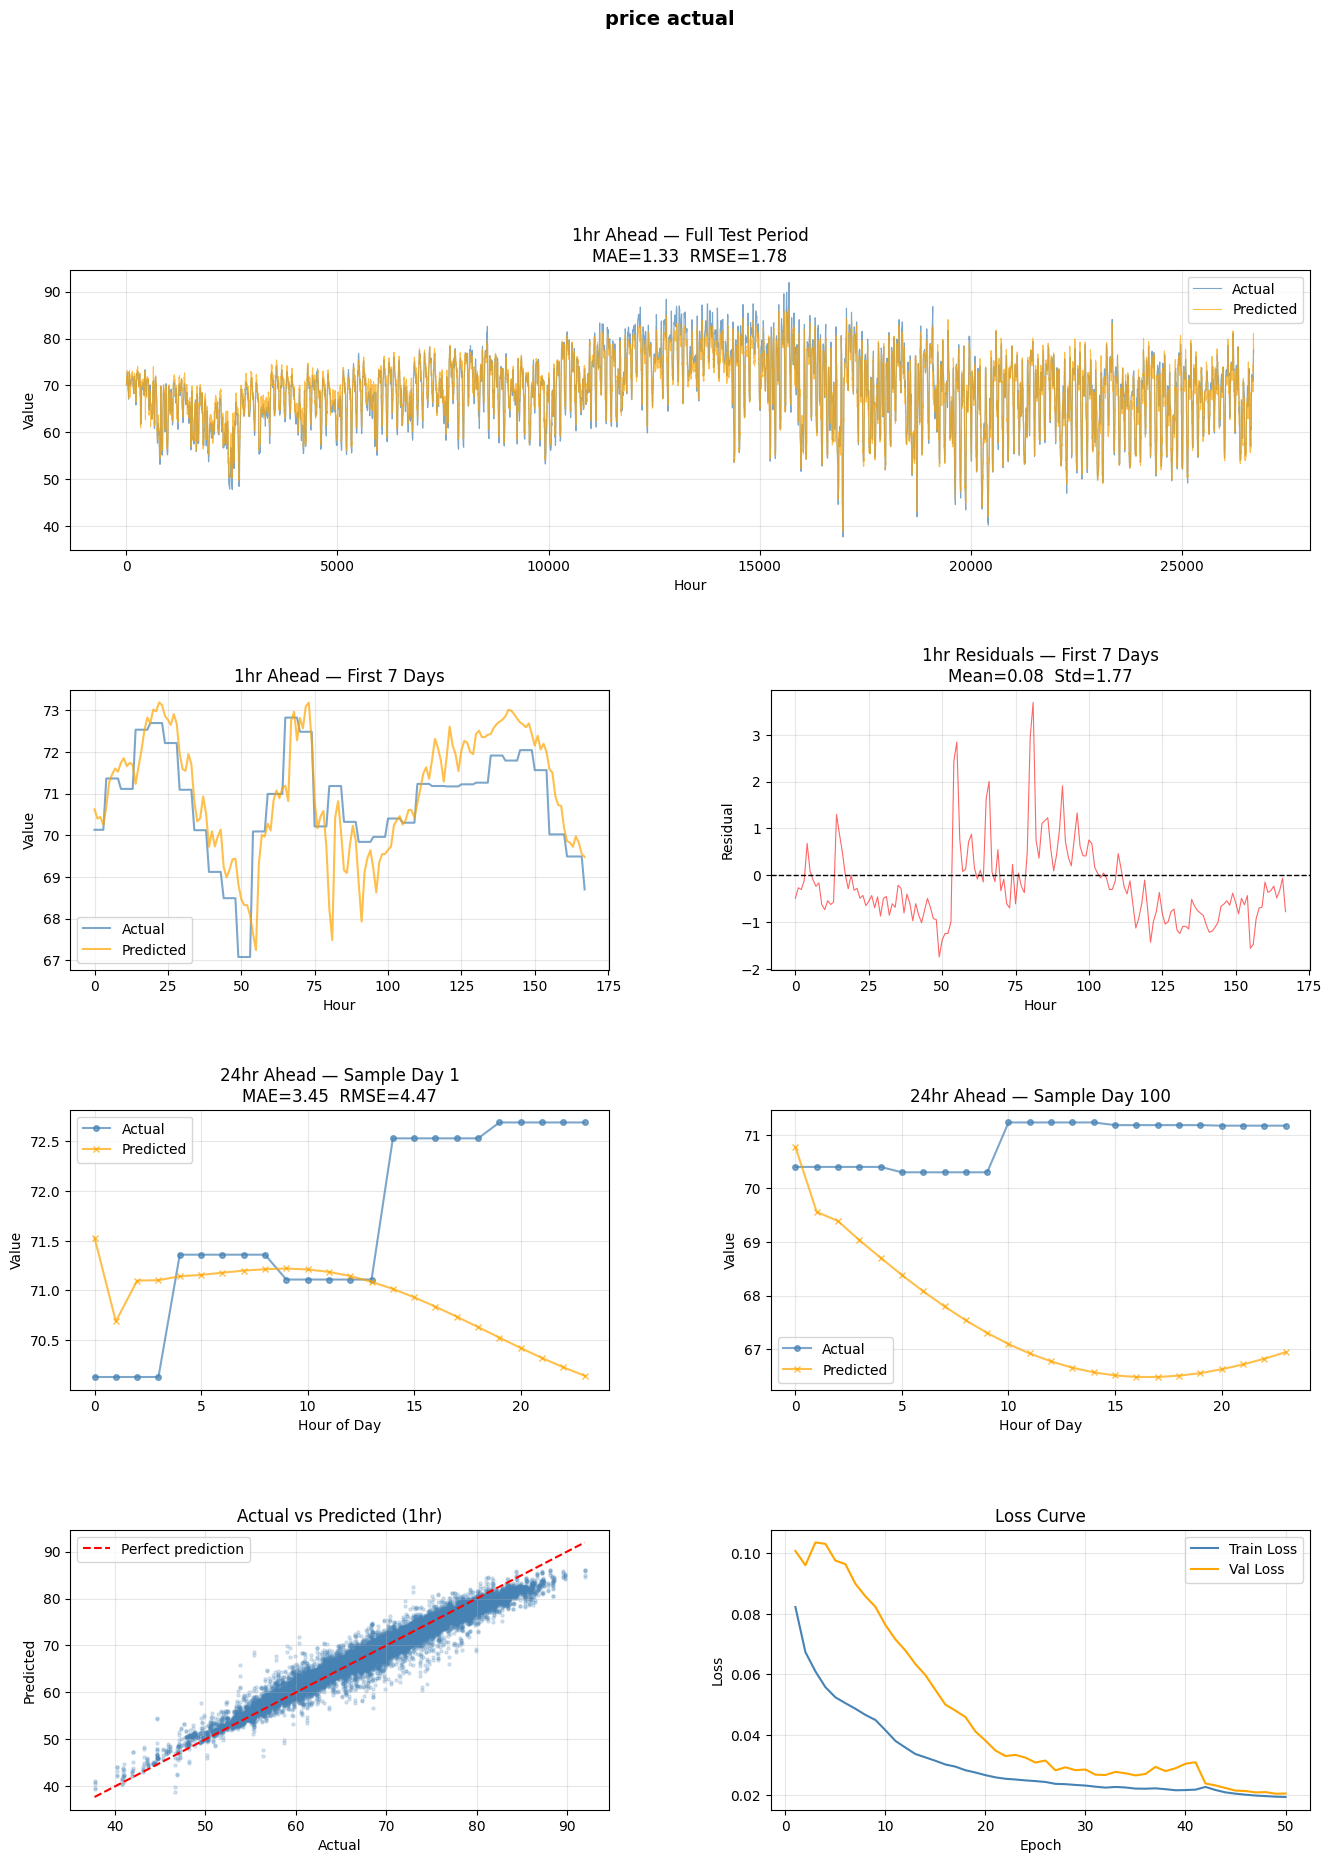

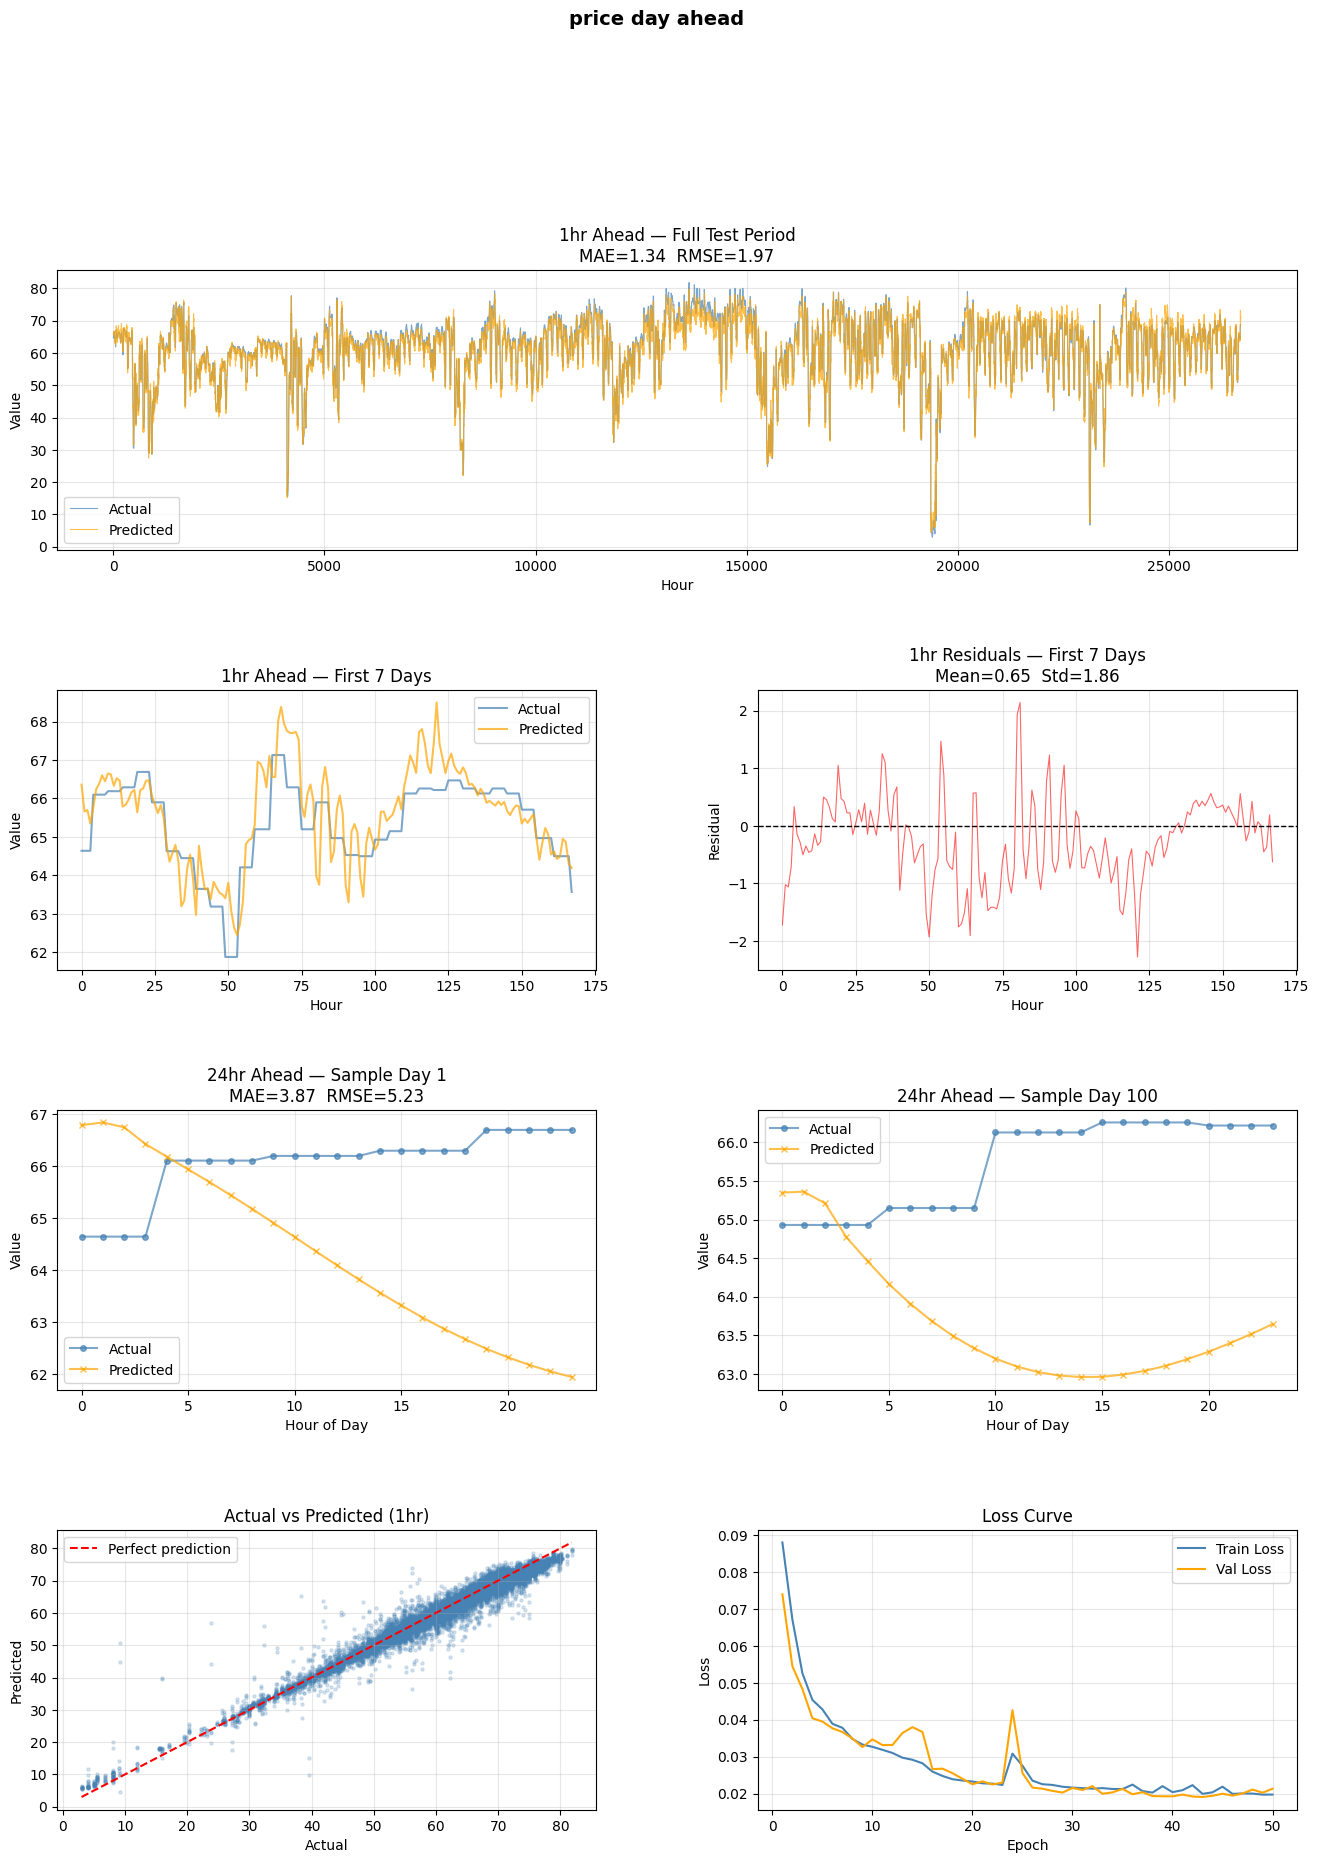

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def evaluate_results(all_results, all_history,
                     target_cols, target_ranges):

    # ── 1. Metrics table ─────────────────────────────────
    print(f"\n{'='*75}")
    print(f"TEST RESULTS — FOLD 5")
    print(f"{'='*75}")
    print(f"\n{'Target':<30} {'1hr MAE':>9} {'1hr RMSE':>10} "
          f"{'24hr MAE':>10} {'24hr RMSE':>11} "
          f"{'MAE%':>7} {'Status'}")
    print("-" * 85)

    for target in target_cols:
        m       = all_results[target]['metrics']
        r       = m['test_range']
        mae_pct = m['1hr']['mae_pct']

        status  = '✅ Good' if mae_pct < 10 else \
                  '⚠️  OK'  if mae_pct < 20 else \
                  '❌ High'

        print(f"{target:<30} "
              f"{r['range']:>12.2f} "
              f"{m['1hr']['mae']:>9.2f} "
              f"{m['1hr']['rmse']:>10.2f} "
              f"{m['24hr']['mae']:>10.2f} "
              f"{m['24hr']['rmse']:>11.2f} "
              f"{mae_pct:>8.1f}% "
              f"  {status}")

    # ── 2. Plots per target ───────────────────────────────
    for target in target_cols:

        preds_1hr    = all_results[target]['preds_1hr']
        preds_24hr   = all_results[target]['preds_24hr']
        actuals_1hr  = all_results[target]['actuals_1hr']
        actuals_24hr = all_results[target]['actuals_24hr']
        metrics      = all_results[target]['metrics']
        history      = all_history[target]

        fig = plt.figure(figsize=(16, 20))
        fig.suptitle(f'{target}', 
                     fontsize=14, fontweight='bold', y=1.01)

        gs = gridspec.GridSpec(4, 2, figure=fig,
                               hspace=0.5, wspace=0.3)

        # ── Plot 1: Full test period 1hr ─────────────
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(actuals_1hr.flatten(),
                 label='Actual',
                 alpha=0.7, color='steelblue', linewidth=0.8)
        ax1.plot(preds_1hr.flatten(),
                 label='Predicted',
                 alpha=0.7, color='orange', linewidth=0.8)
        ax1.set_title(
            f'1hr Ahead — Full Test Period\n'
            f'MAE={metrics["1hr"]["mae"]:.2f}  '
            f'RMSE={metrics["1hr"]["rmse"]:.2f}')
        ax1.set_xlabel('Hour')
        ax1.set_ylabel('Value')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # ── Plot 2: Zoomed 7 days 1hr ─────────────────
        ax2 = fig.add_subplot(gs[1, 0])
        ax2.plot(actuals_1hr[:168].flatten(),
                 label='Actual',
                 alpha=0.7, color='steelblue')
        ax2.plot(preds_1hr[:168].flatten(),
                 label='Predicted',
                 alpha=0.7, color='orange')
        ax2.set_title('1hr Ahead — First 7 Days')
        ax2.set_xlabel('Hour')
        ax2.set_ylabel('Value')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # ── Plot 3: Residuals 1hr ─────────────────────
        ax3 = fig.add_subplot(gs[1, 1])
        residuals_1hr = actuals_1hr.flatten() - \
                        preds_1hr.flatten()
        ax3.plot(residuals_1hr[:168],
                 color='red', alpha=0.6, linewidth=0.8)
        ax3.axhline(y=0, color='black',
                    linestyle='--', linewidth=1)
        ax3.set_title(
            f'1hr Residuals — First 7 Days\n'
            f'Mean={residuals_1hr.mean():.2f}  '
            f'Std={residuals_1hr.std():.2f}')
        ax3.set_xlabel('Hour')
        ax3.set_ylabel('Residual')
        ax3.grid(True, alpha=0.3)

        # ── Plot 4: 24hr ahead — one sample ──────────
        ax4 = fig.add_subplot(gs[2, 0])
        sample_idx = 0   # first sample
        ax4.plot(range(24),
                 actuals_24hr[sample_idx],
                 label='Actual',
                 alpha=0.7, color='steelblue',
                 marker='o', markersize=4)
        ax4.plot(range(24),
                 preds_24hr[sample_idx],
                 label='Predicted',
                 alpha=0.7, color='orange',
                 marker='x', markersize=4)
        ax4.set_title(
            f'24hr Ahead — Sample Day 1\n'
            f'MAE={metrics["24hr"]["mae"]:.2f}  '
            f'RMSE={metrics["24hr"]["rmse"]:.2f}')
        ax4.set_xlabel('Hour of Day')
        ax4.set_ylabel('Value')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # ── Plot 5: 24hr ahead — another sample ──────
        ax5 = fig.add_subplot(gs[2, 1])
        sample_idx = 100  # different day
        ax5.plot(range(24),
                 actuals_24hr[sample_idx],
                 label='Actual',
                 alpha=0.7, color='steelblue',
                 marker='o', markersize=4)
        ax5.plot(range(24),
                 preds_24hr[sample_idx],
                 label='Predicted',
                 alpha=0.7, color='orange',
                 marker='x', markersize=4)
        ax5.set_title(f'24hr Ahead — Sample Day 100')
        ax5.set_xlabel('Hour of Day')
        ax5.set_ylabel('Value')
        ax5.legend()
        ax5.grid(True, alpha=0.3)

        # ── Plot 6: Scatter plot actual vs predicted ──
        ax6 = fig.add_subplot(gs[3, 0])
        ax6.scatter(actuals_1hr.flatten(),
                    preds_1hr.flatten(),
                    alpha=0.2, color='steelblue',
                    s=5)
        # perfect prediction line
        min_val = min(actuals_1hr.min(), preds_1hr.min())
        max_val = max(actuals_1hr.max(), preds_1hr.max())
        ax6.plot([min_val, max_val],
                 [min_val, max_val],
                 'r--', linewidth=1.5,
                 label='Perfect prediction')
        ax6.set_title('Actual vs Predicted (1hr)')
        ax6.set_xlabel('Actual')
        ax6.set_ylabel('Predicted')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

        # ── Plot 7: Loss curves ───────────────────────
        ax7 = fig.add_subplot(gs[3, 1])
        epochs = range(1, len(history['train_loss']) + 1)
        ax7.plot(epochs, history['train_loss'],
                 label='Train Loss',
                 color='steelblue', linewidth=1.5)
        ax7.plot(epochs, history['val_loss'],
                 label='Val Loss',
                 color='orange', linewidth=1.5)
        ax7.set_title(f'Loss Curve')
        ax7.set_xlabel('Epoch')
        ax7.set_ylabel('Loss')
        ax7.legend()
        ax7.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


# ── Run evaluation ────────────────────────────────────────
# target_ranges = {
#     'generation solar'       : 5783.00,
#     'generation wind onshore': 17202.00,
#     'total load actual'      : 22974.00,
#     'price actual'           : 107.47,
#     'price day ahead'        : 99.69
# }

evaluate_results(
    all_results,
    all_history,
    target_cols
)


TEST RESULTS SUMMARY — ALL TARGETS — FOLD 5

Target                           1hr MAE   1hr RMSE   24hr MAE   24hr RMSE    MAE% Status
-------------------------------------------------------------------------------------
generation solar                   60.09     103.97     201.73      369.72    1.0%   ✅ Good
generation wind onshore           136.06     331.86     598.04      985.52    0.8%   ✅ Good
total load actual                 248.25     370.93     788.65     1117.08    1.1%   ✅ Good
price actual                        1.33       1.78       3.45        4.47    1.2%   ✅ Good
price day ahead                     1.34       1.97       3.87        5.23    1.3%   ✅ Good


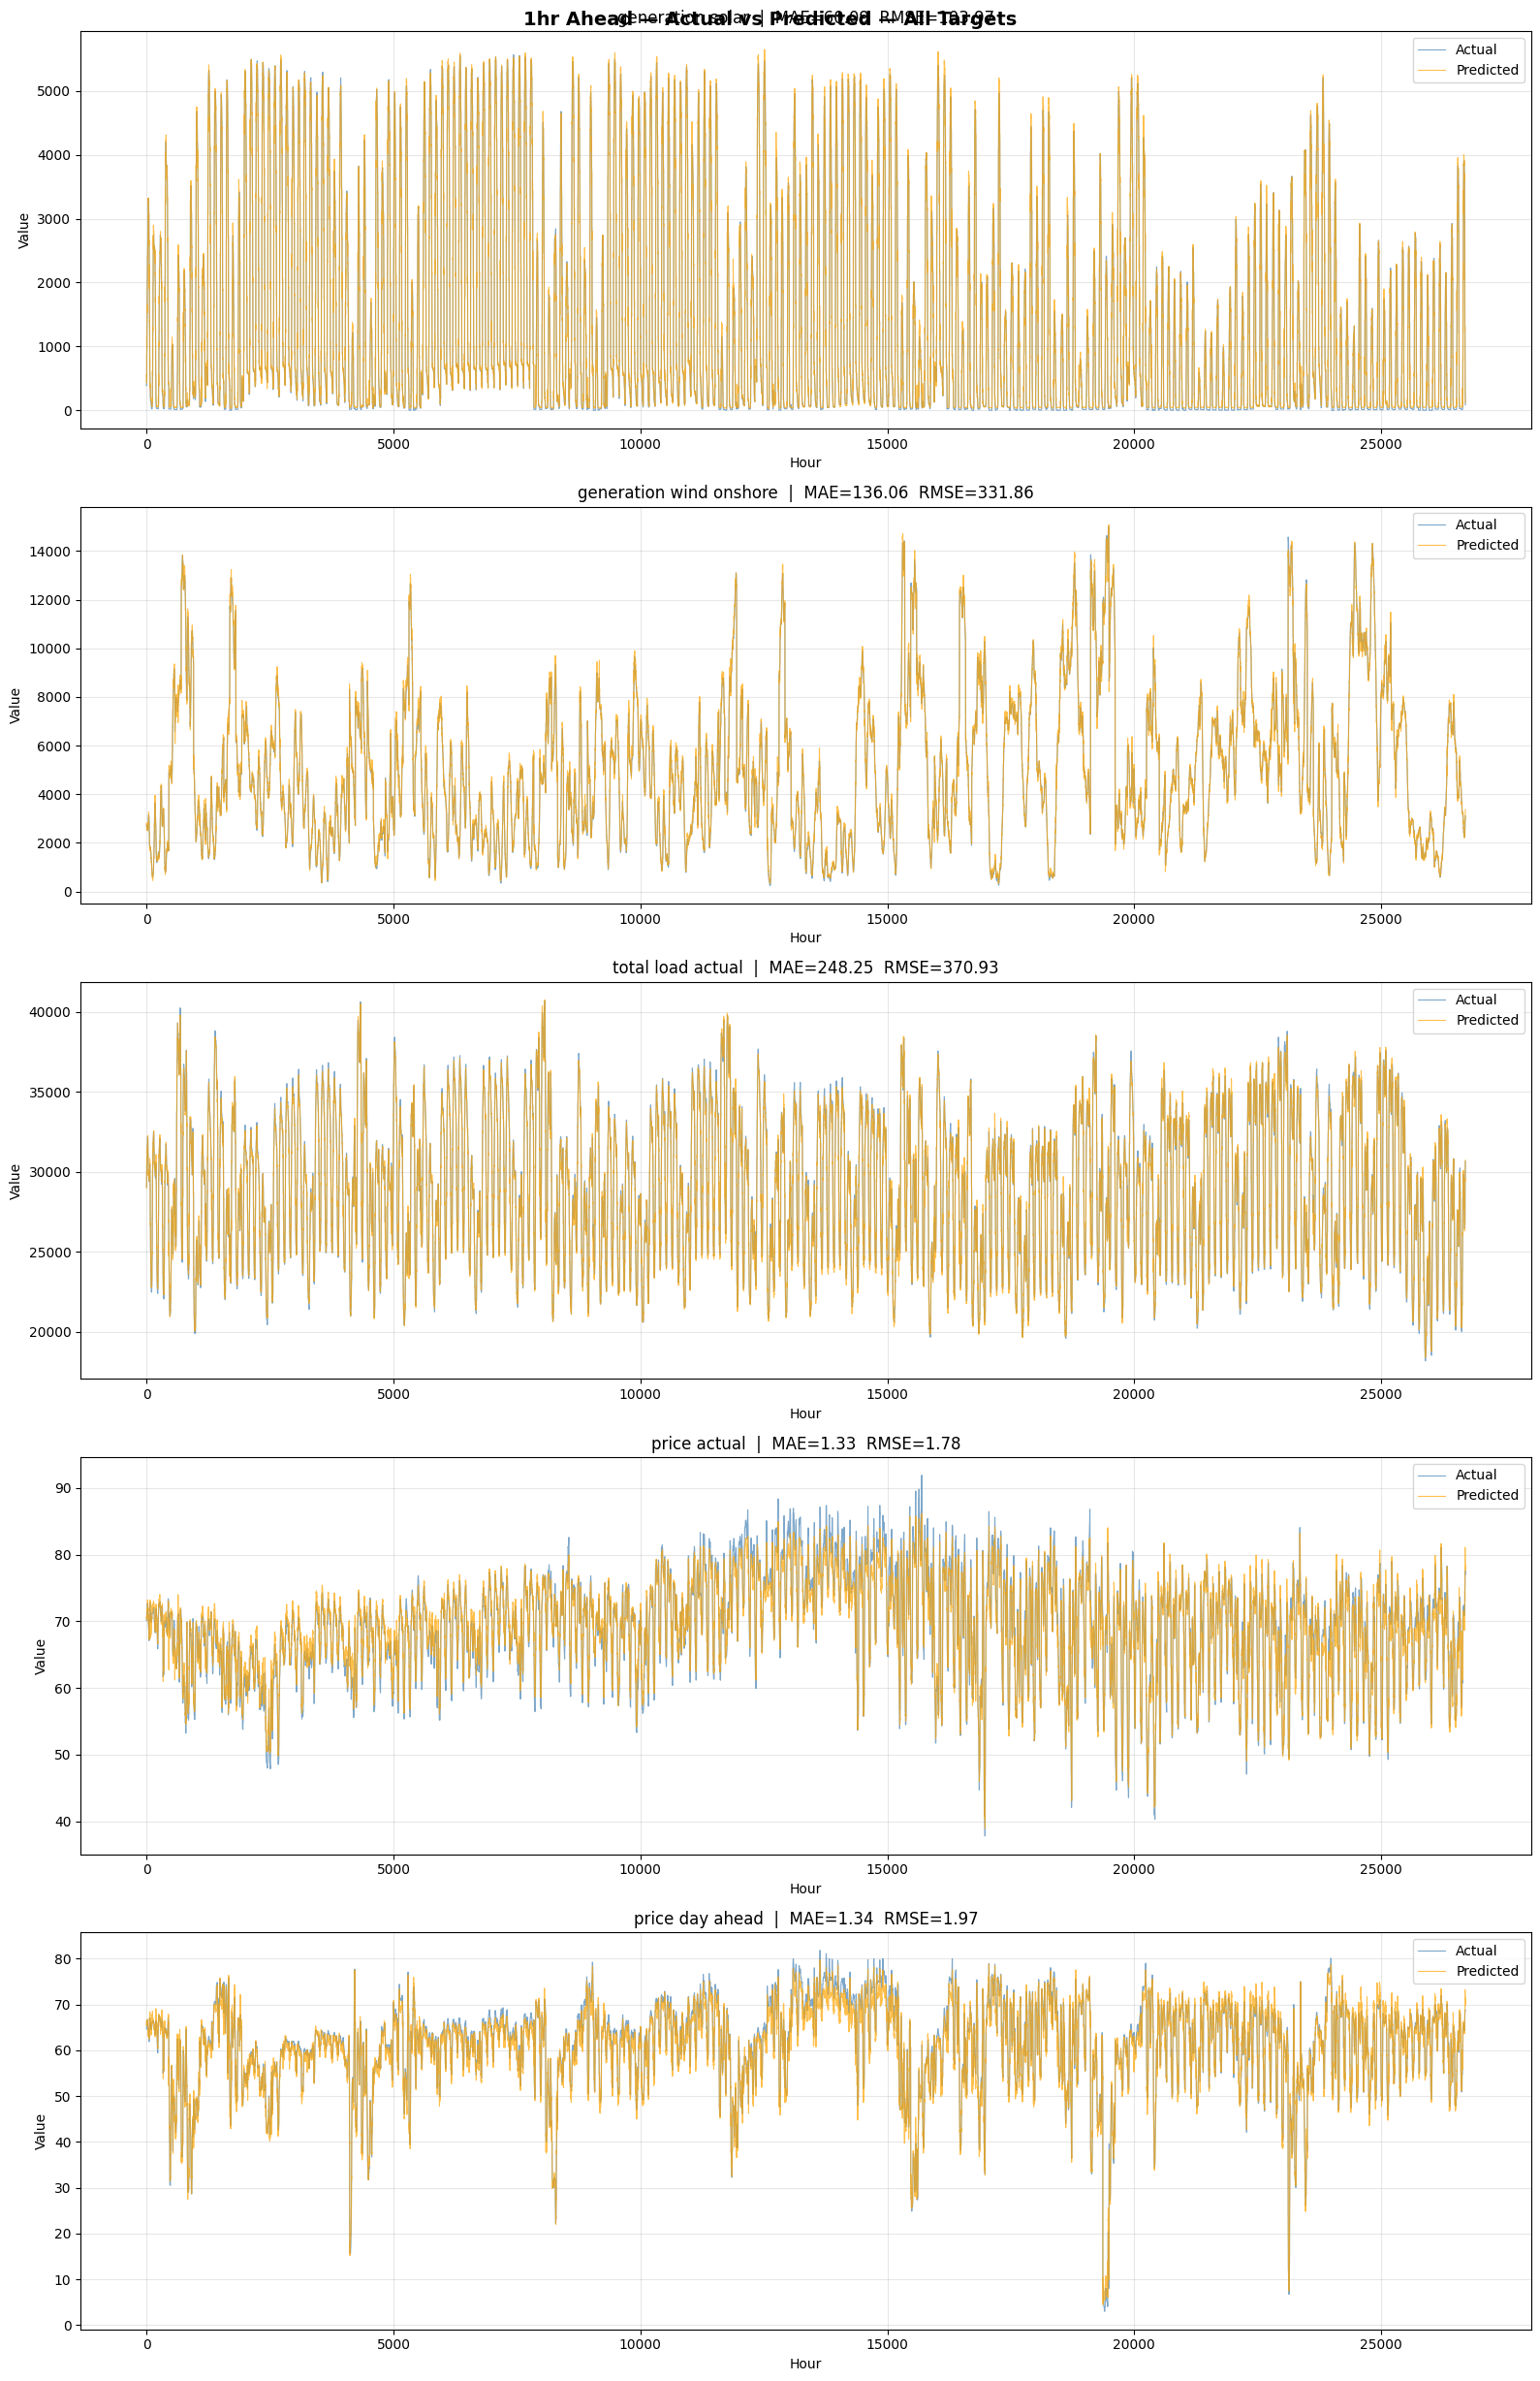

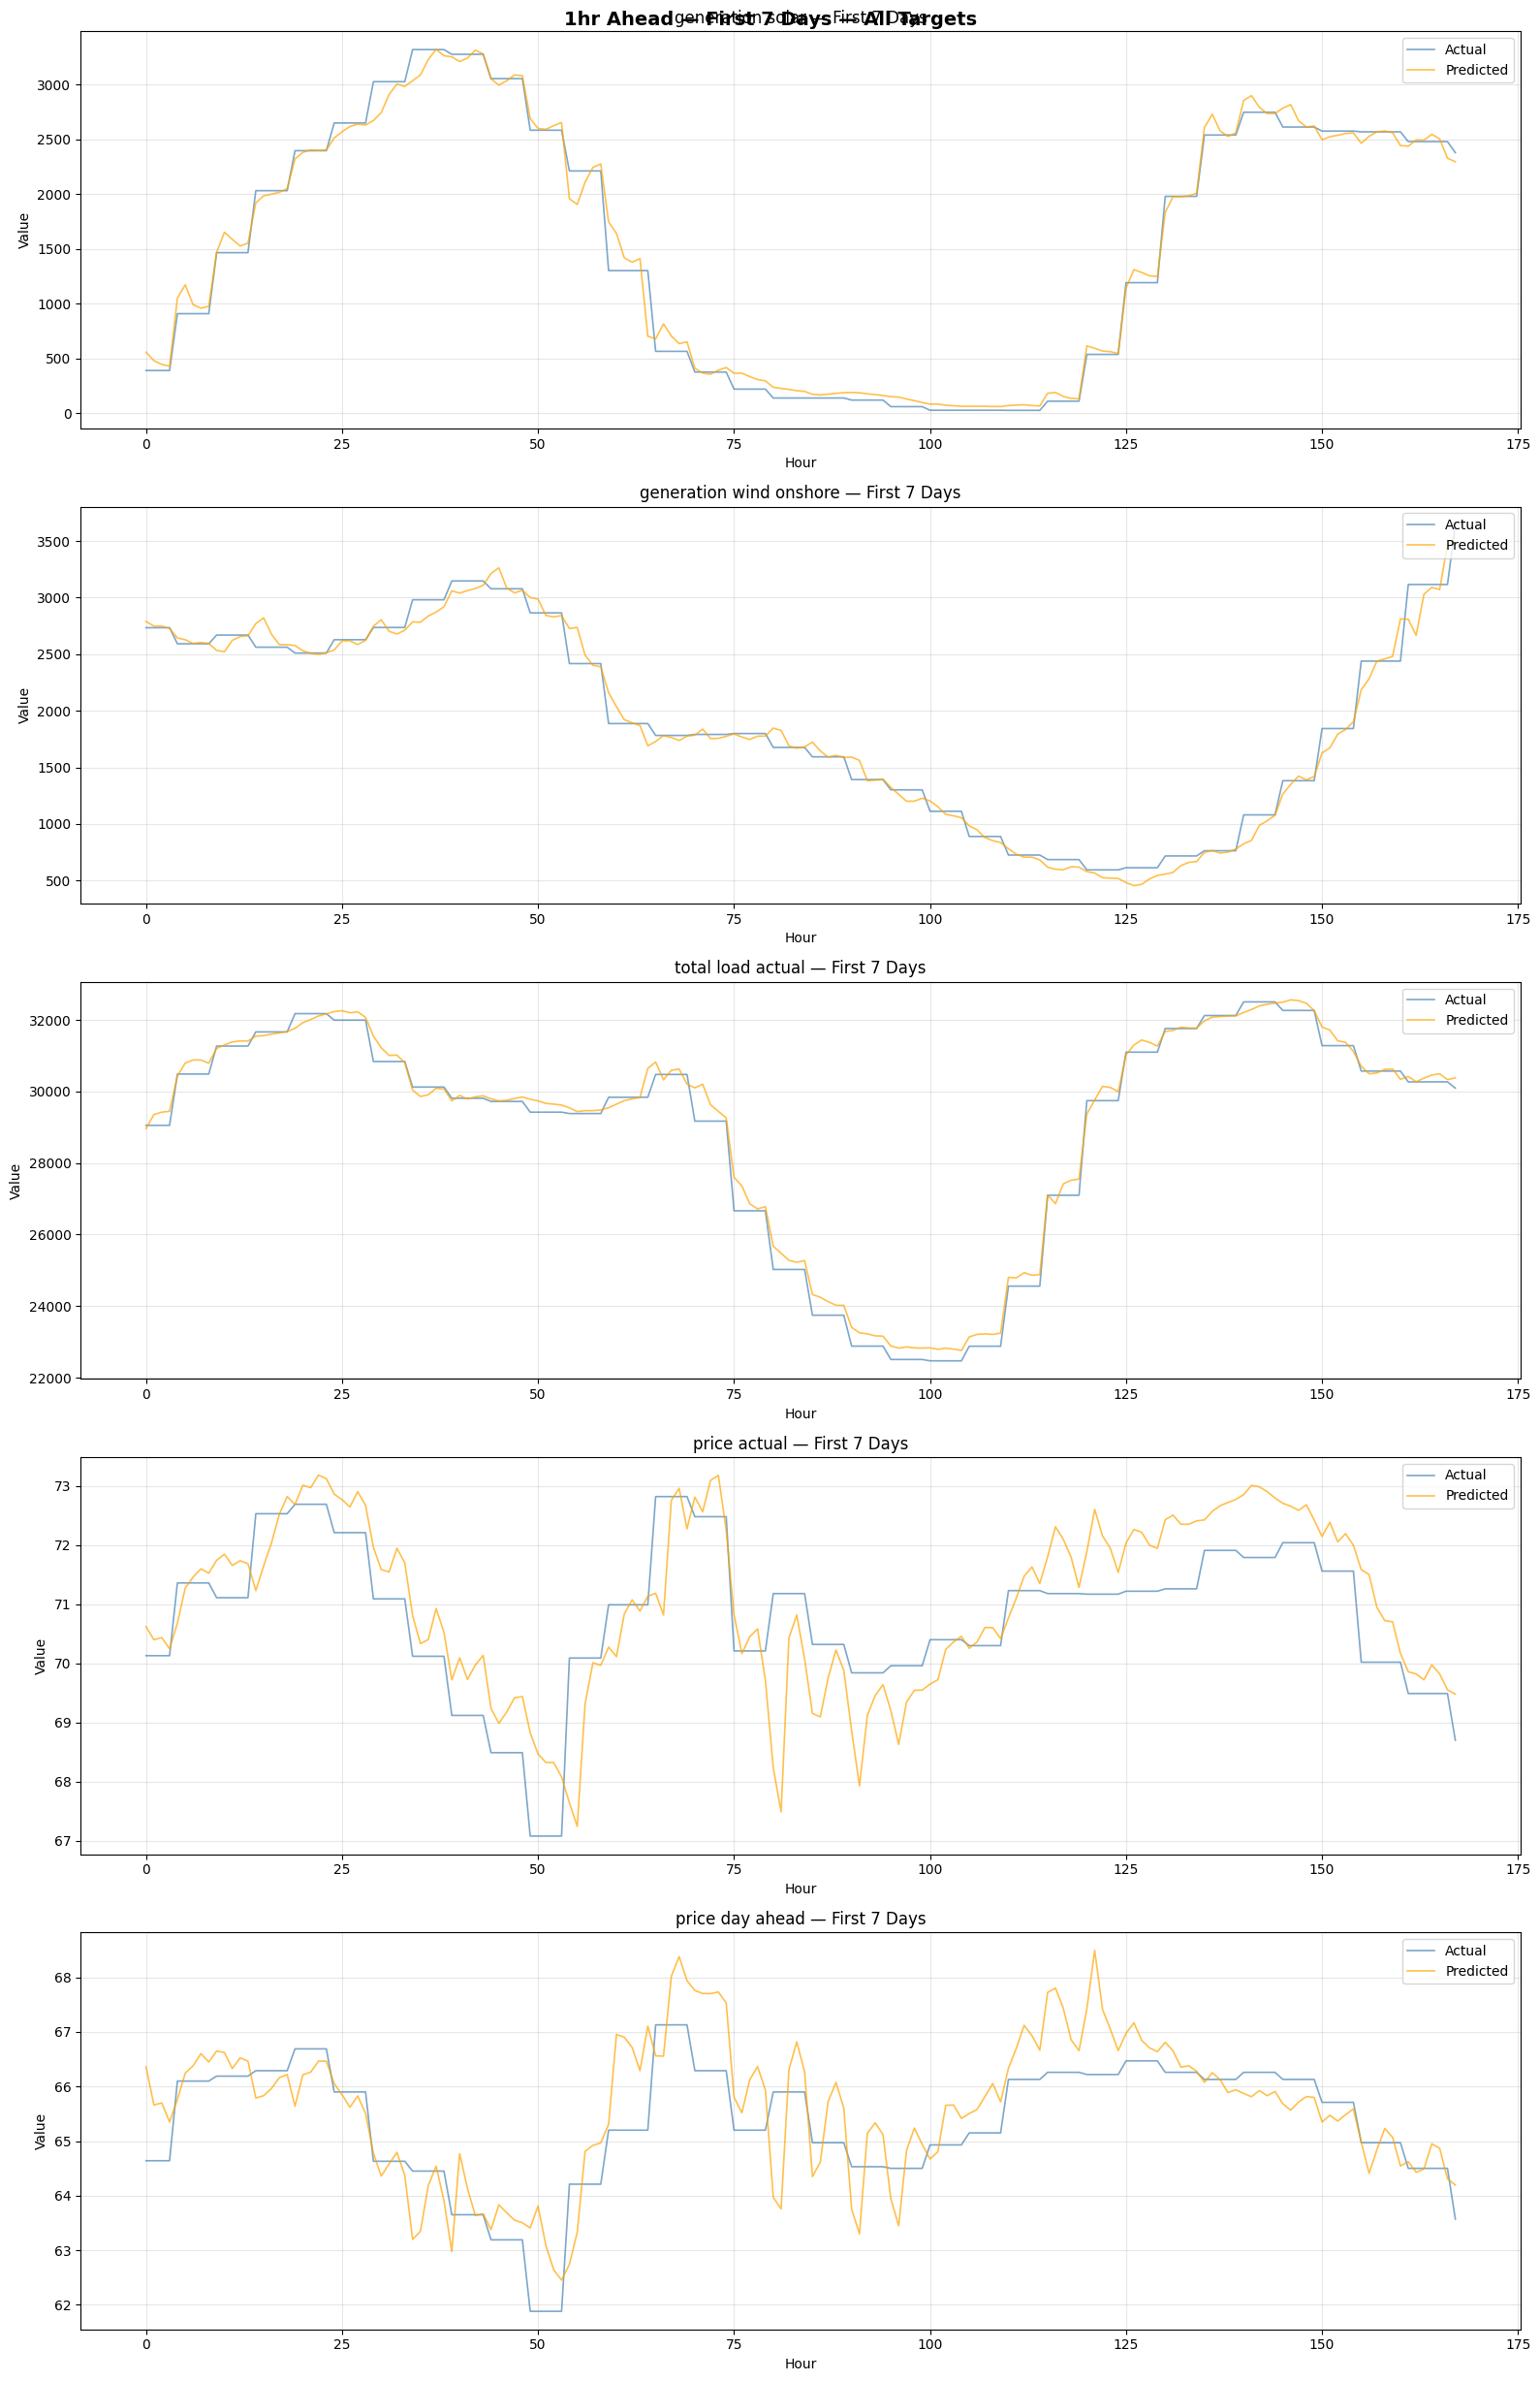

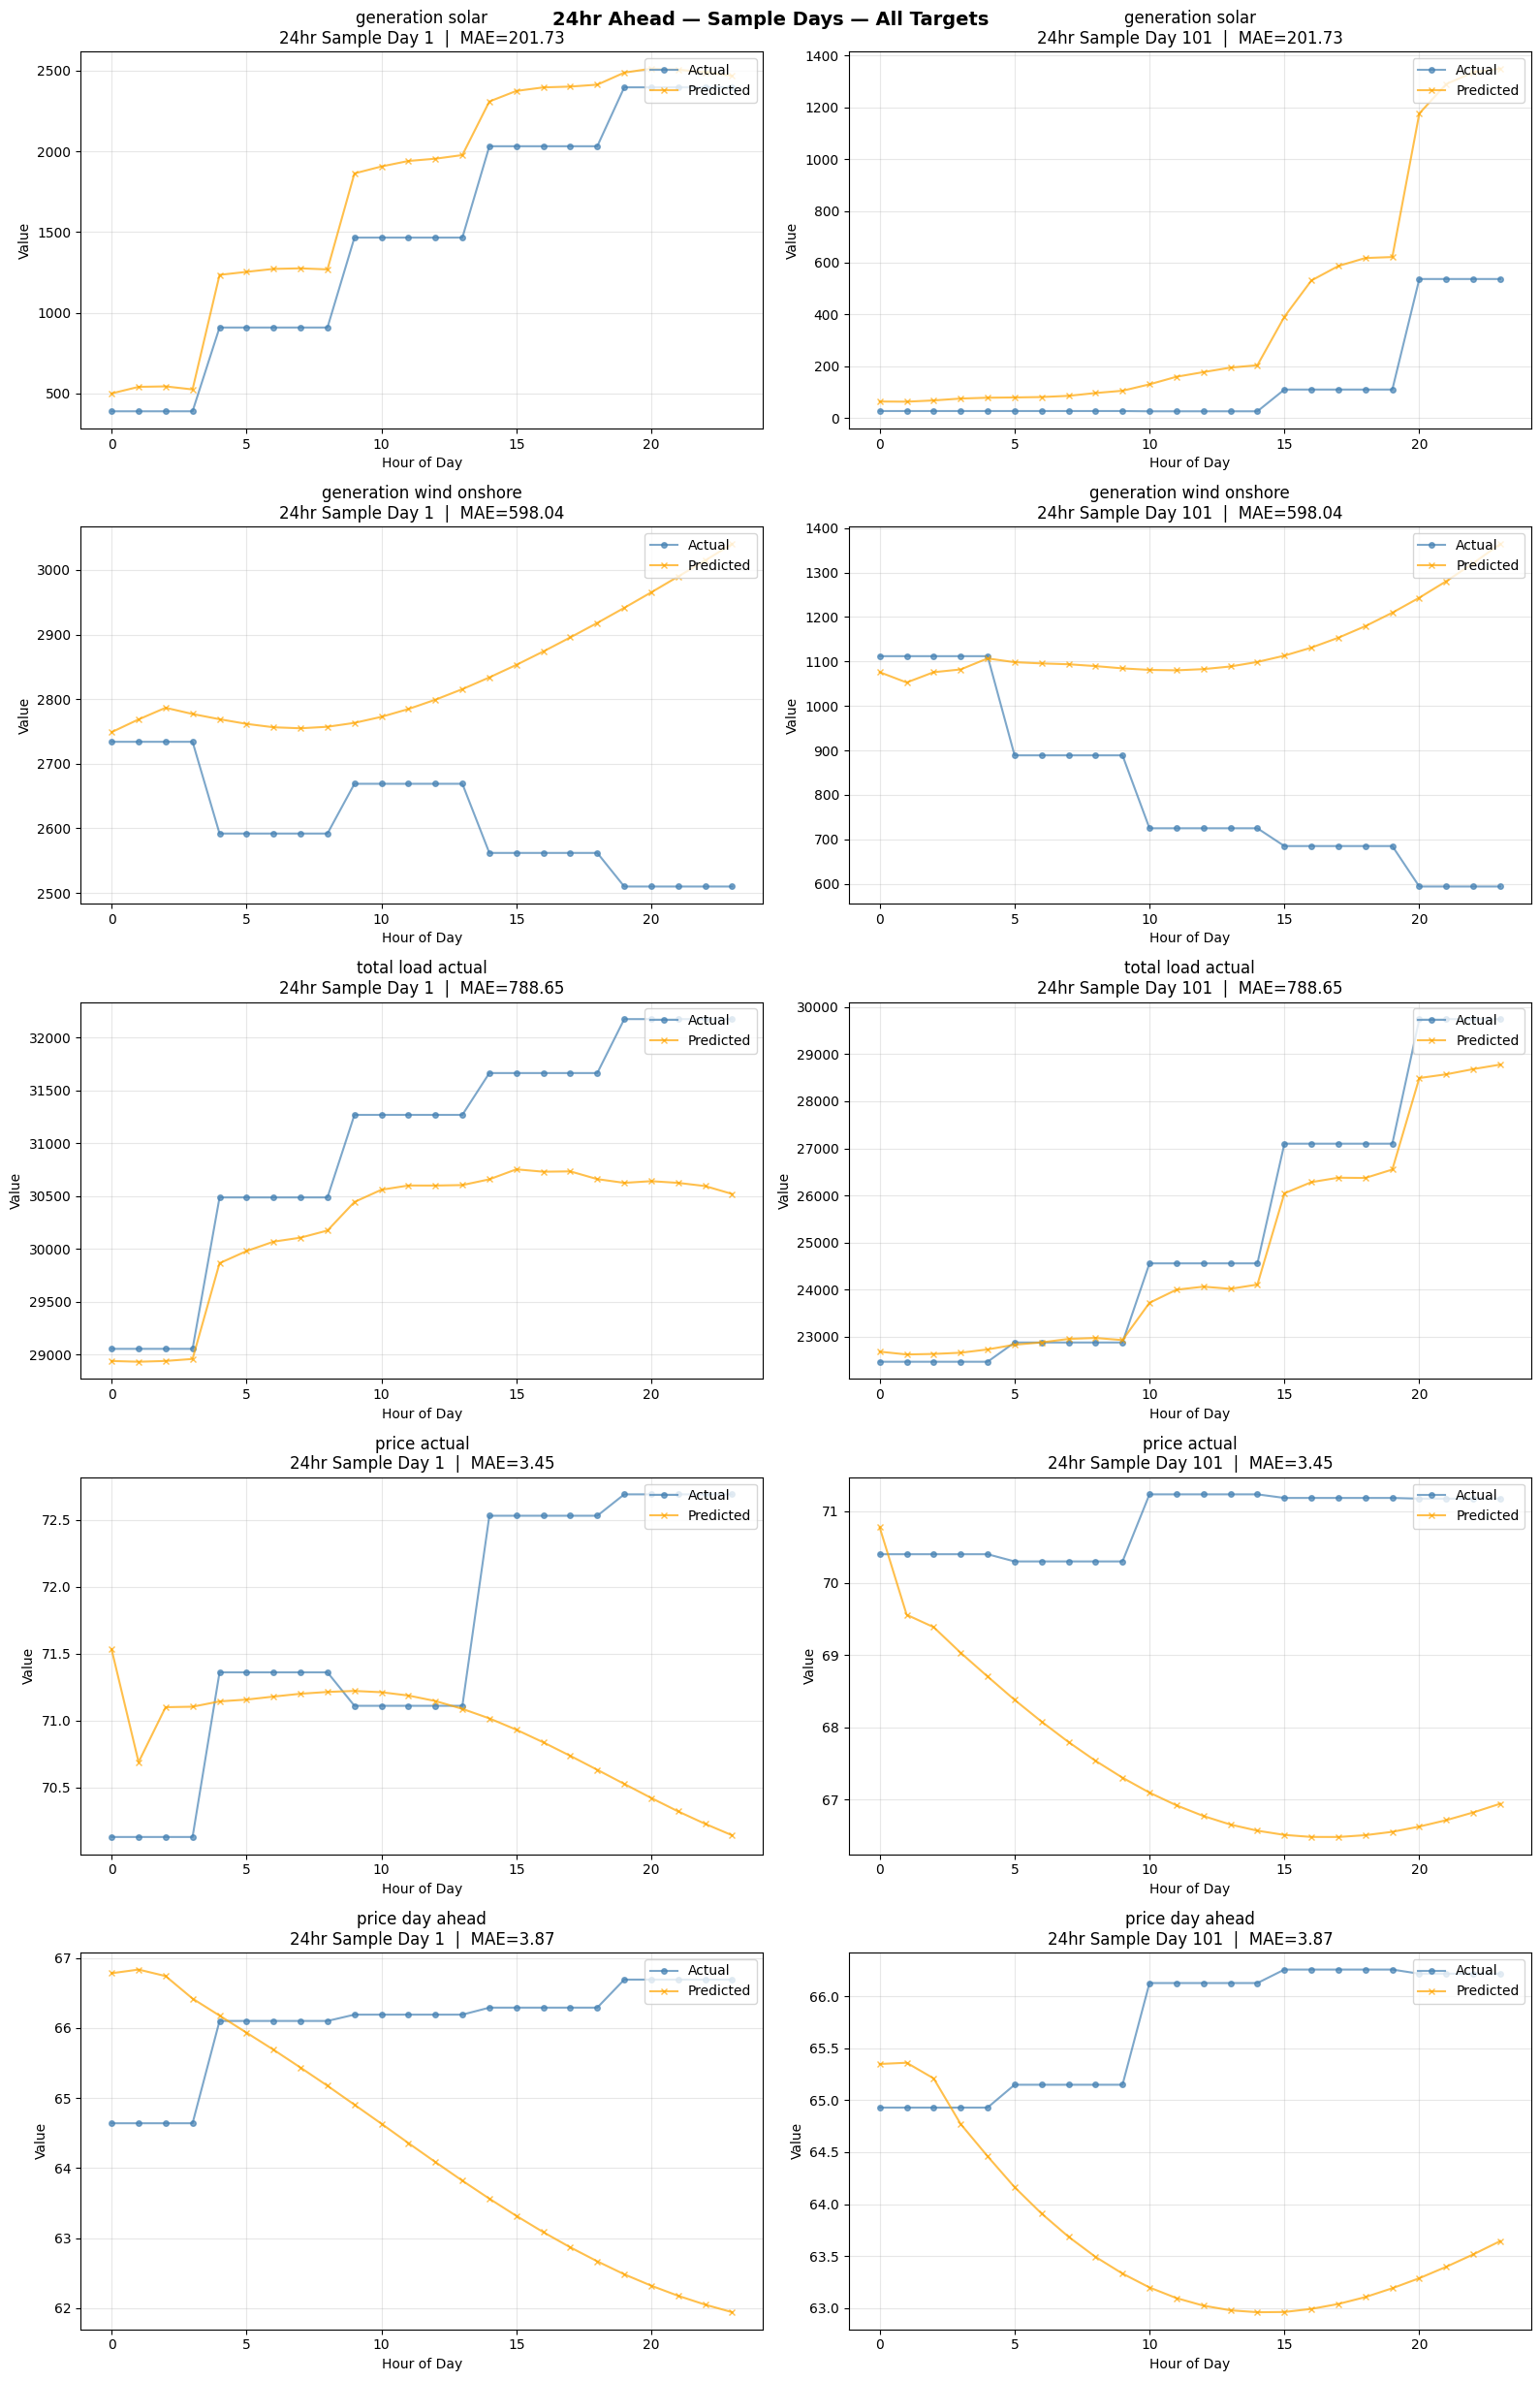

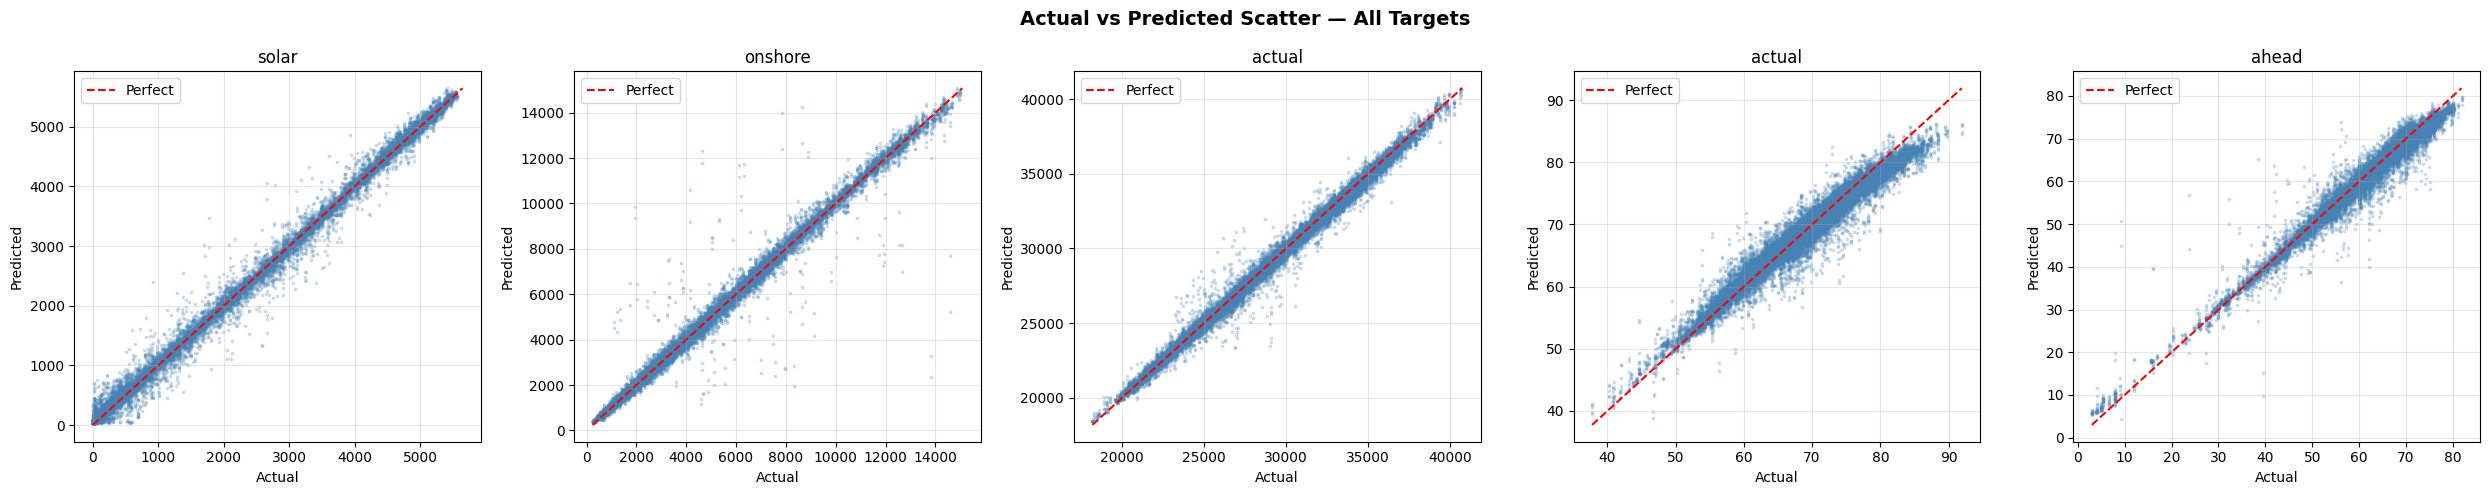

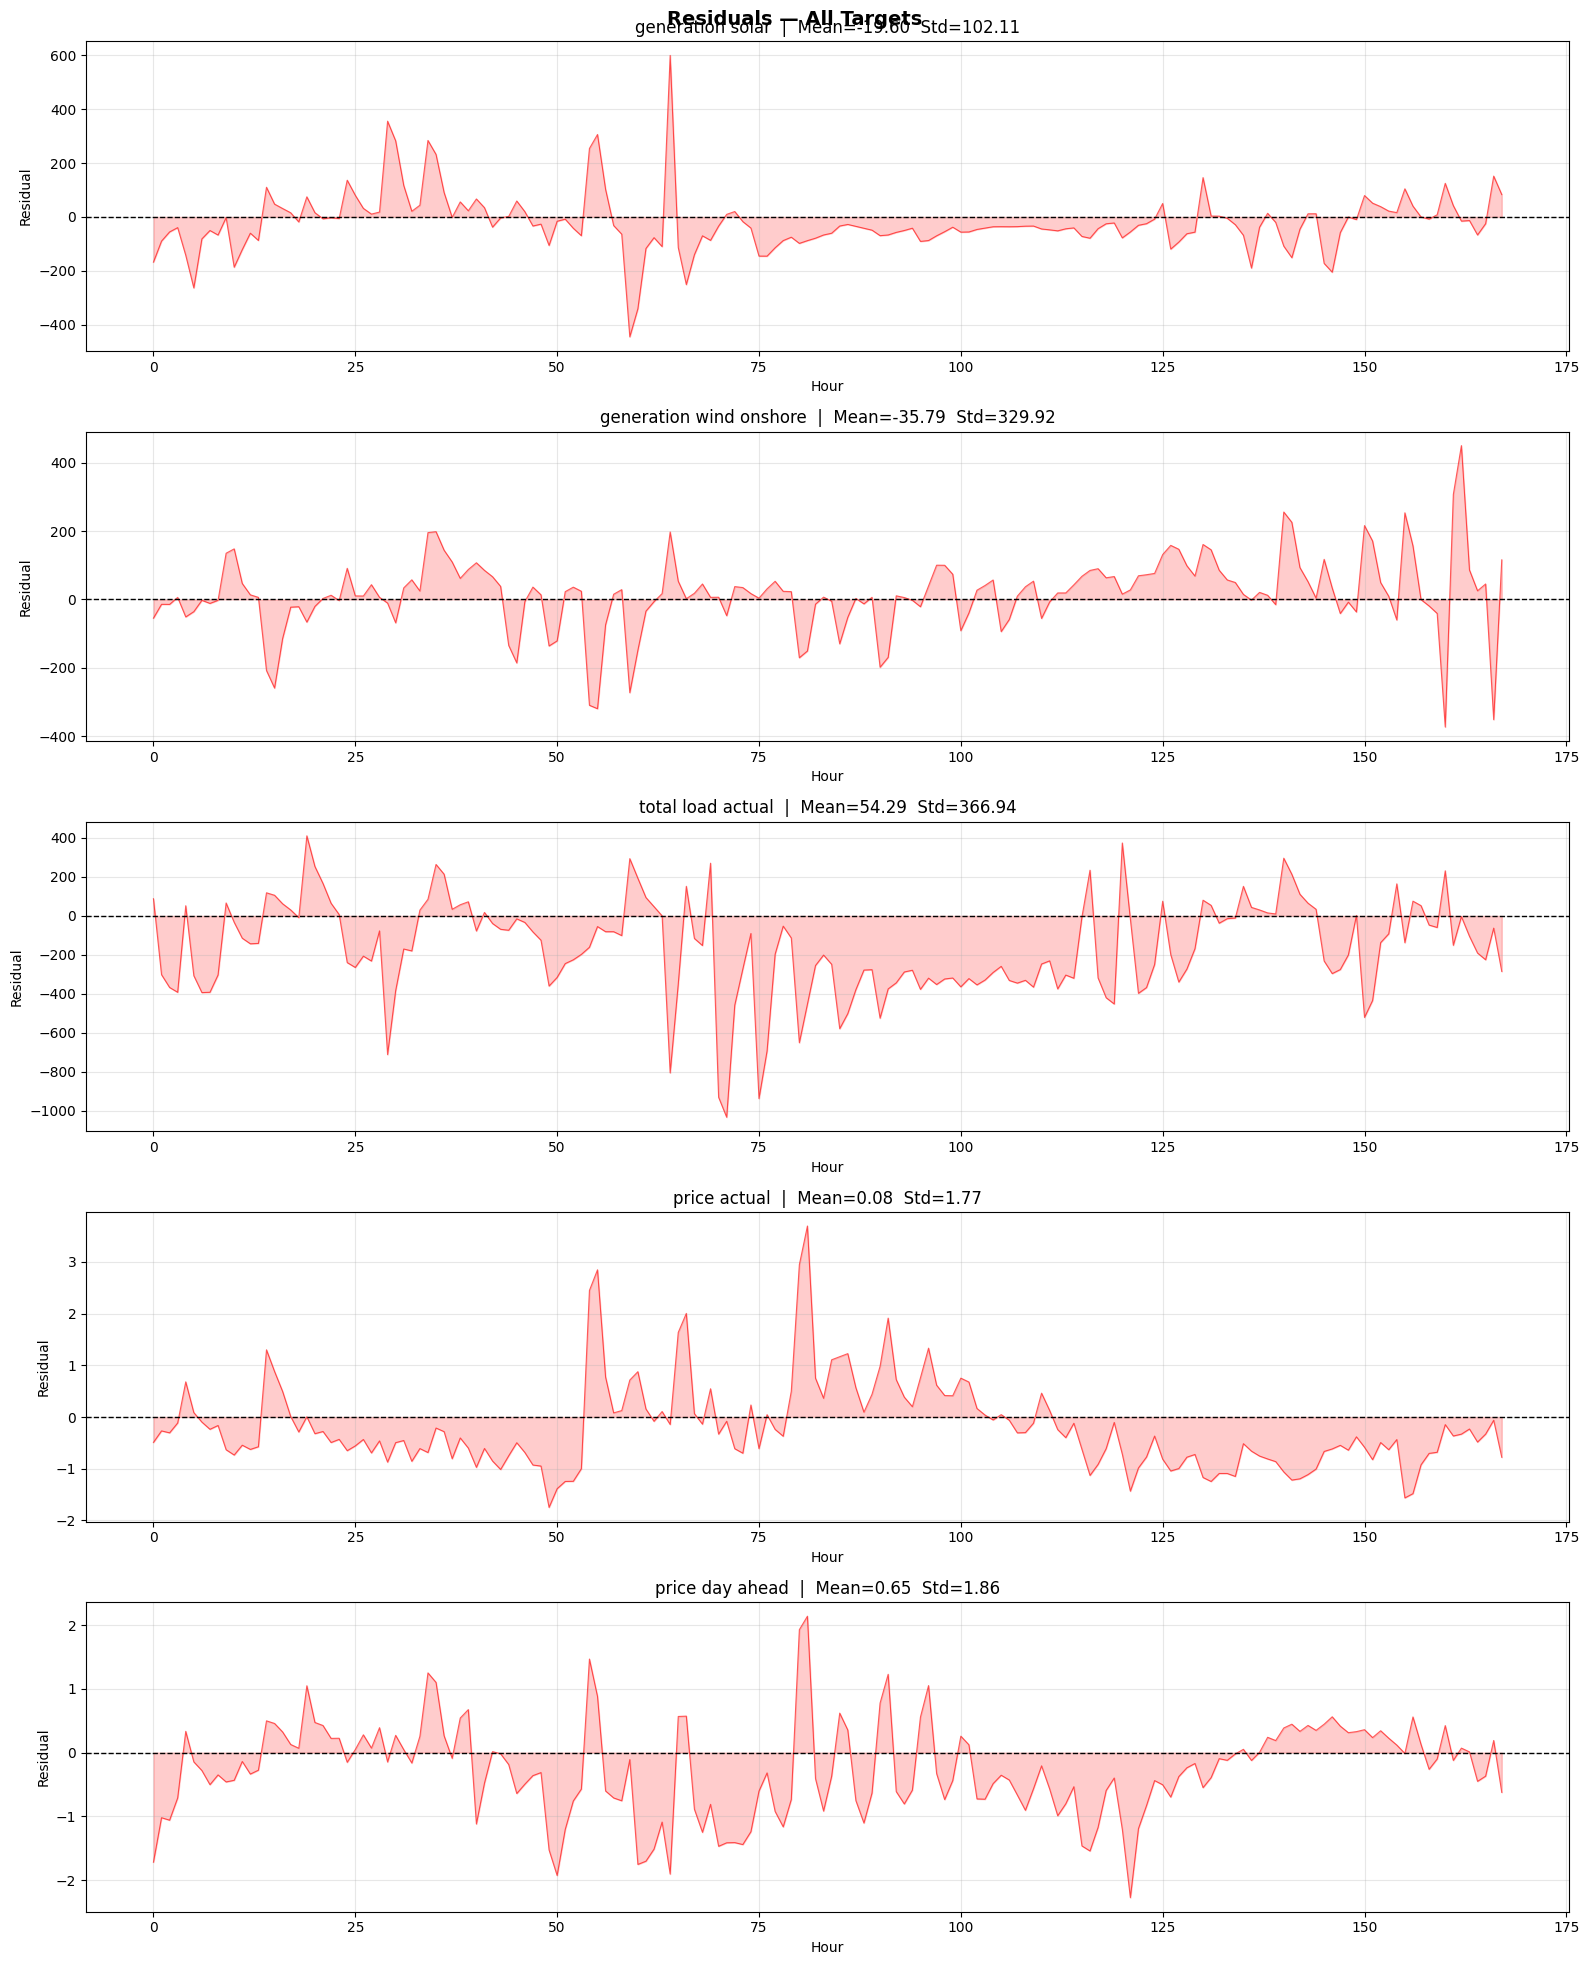

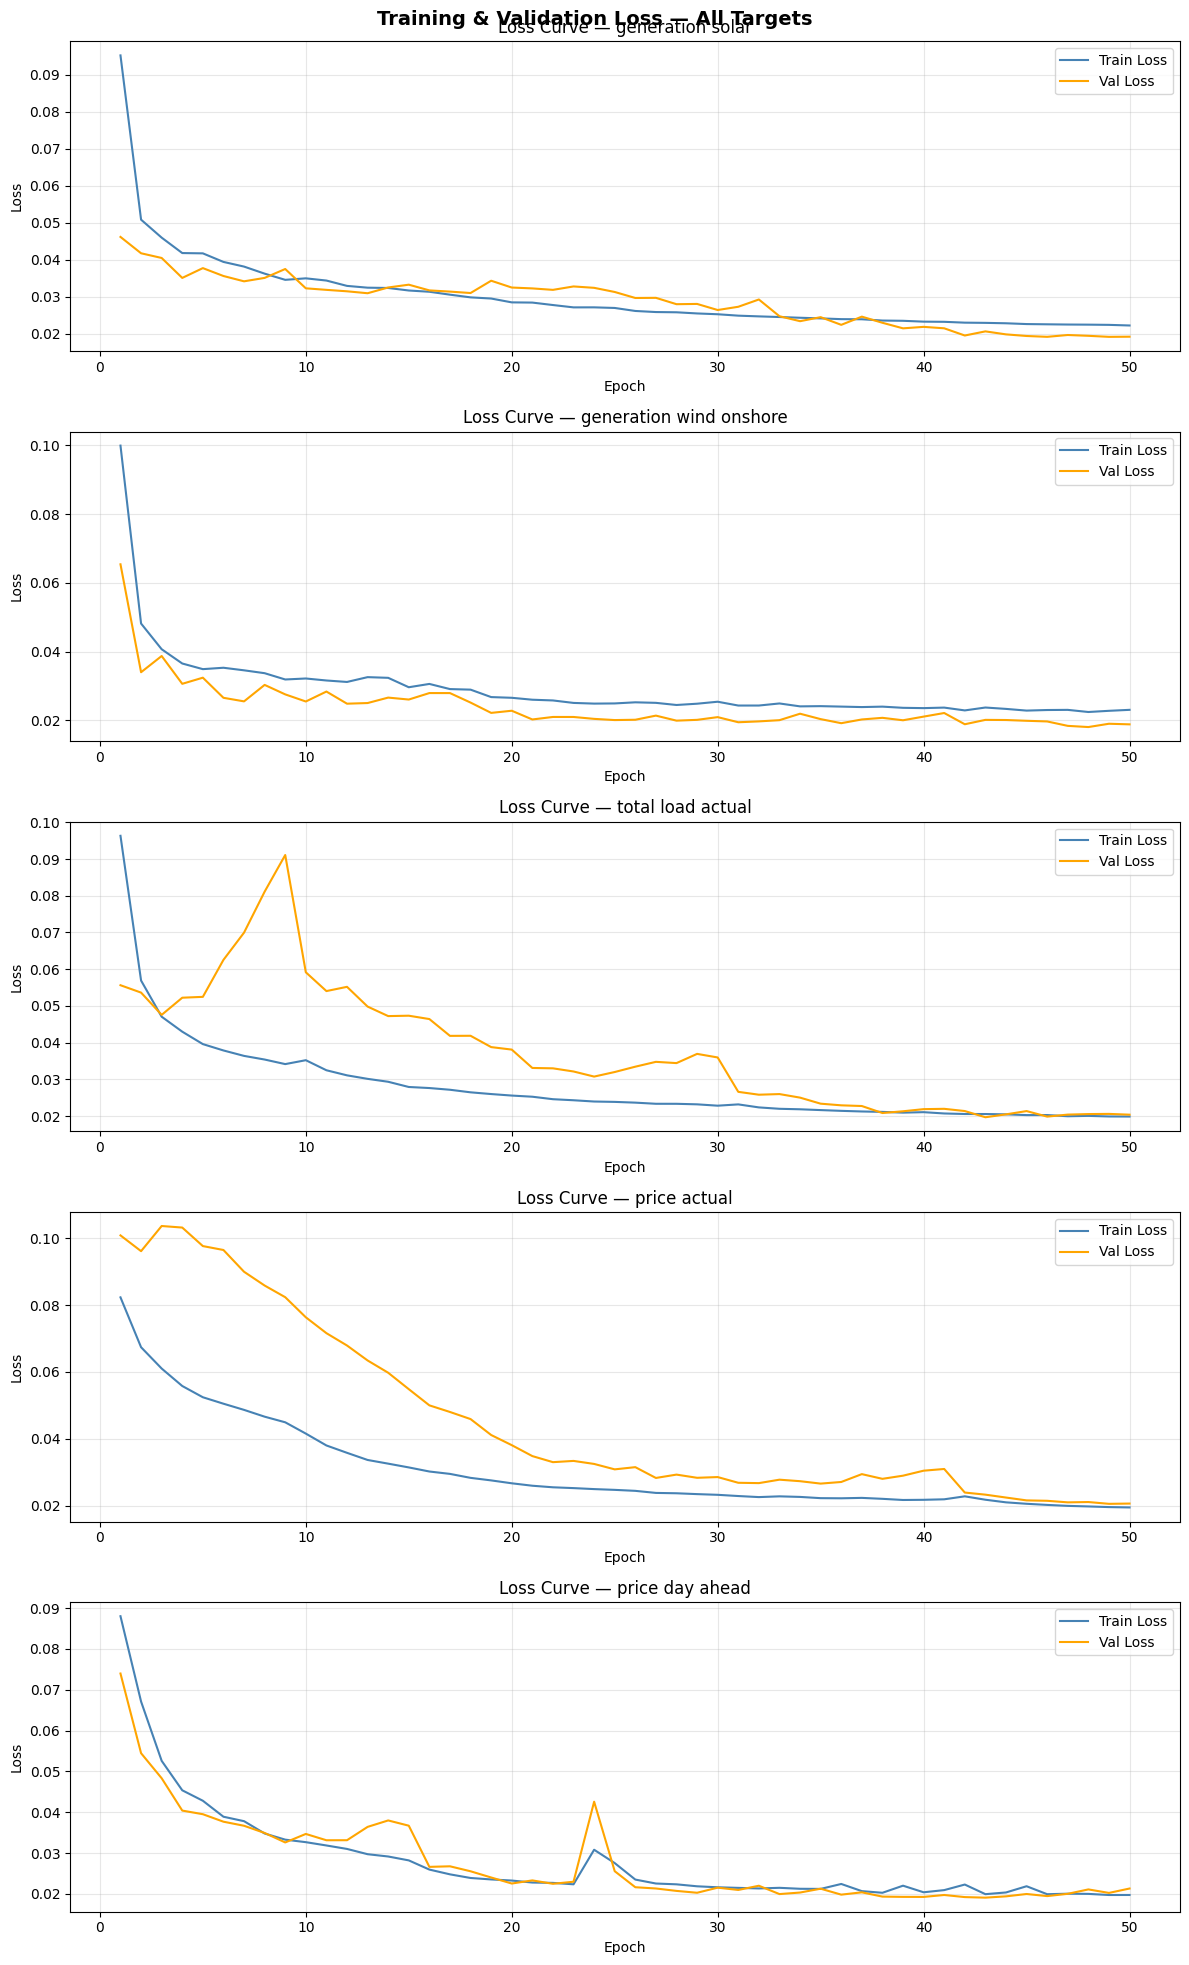

In [ ]:
def plot_all_targets(all_results, all_history,
                     target_cols):

    # ── 1. Summary metrics table ──────────────────────────
    print(f"\n{'='*85}")
    print(f"TEST RESULTS SUMMARY — ALL TARGETS — FOLD 5")
    print(f"{'='*85}")
    print(f"\n{'Target':<30} {'1hr MAE':>9} {'1hr RMSE':>10} "
          f"{'24hr MAE':>10} {'24hr RMSE':>11} "
          f"{'MAE%':>7} {'Status'}")
    print("-" * 85)

    for target in target_cols:
        m       = all_results[target]['metrics']
        r       = m['test_range']
        mae_pct = m['1hr']['mae_pct']
        status  = '✅ Good' if mae_pct < 10 else \
                  '⚠️  OK'  if mae_pct < 20 else \
                  '❌ High'
        print(f"{target:<30} "
              f"{r['range']:>12.2f} "
              f"{m['1hr']['mae']:>9.2f} "
              f"{m['1hr']['rmse']:>10.2f} "
              f"{m['24hr']['mae']:>10.2f} "
              f"{m['24hr']['rmse']:>11.2f} "
              f"{mae_pct:>6.1f}% "
              f"  {status}")

    # ── 2. All targets — 1hr actual vs predicted ──────────
    fig, axes = plt.subplots(
        len(target_cols), 1,
        figsize=(16, 5 * len(target_cols))
    )
    fig.suptitle('1hr Ahead — Actual vs Predicted — All Targets',
                 fontsize=14, fontweight='bold')

    for i, target in enumerate(target_cols):
        preds   = all_results[target]['preds_1hr'].flatten()
        actuals = all_results[target]['actuals_1hr'].flatten()
        m       = all_results[target]['metrics']['1hr']

        axes[i].plot(actuals,
                     label='Actual',
                     color='steelblue',
                     alpha=0.7, linewidth=0.8)
        axes[i].plot(preds,
                     label='Predicted',
                     color='orange',
                     alpha=0.7, linewidth=0.8)
        axes[i].set_title(
            f'{target}  |  '
            f'MAE={m["mae"]:.2f}  RMSE={m["rmse"]:.2f}')
        axes[i].set_xlabel('Hour')
        axes[i].set_ylabel('Value')
        axes[i].legend(loc='upper right')
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── 3. All targets — zoomed 7 days ────────────────────
    fig, axes = plt.subplots(
        len(target_cols), 1,
        figsize=(16, 5 * len(target_cols))
    )
    fig.suptitle('1hr Ahead — First 7 Days — All Targets',
                 fontsize=14, fontweight='bold')

    for i, target in enumerate(target_cols):
        preds   = all_results[target]['preds_1hr'].flatten()
        actuals = all_results[target]['actuals_1hr'].flatten()

        axes[i].plot(actuals[:168],
                     label='Actual',
                     color='steelblue',
                     alpha=0.7, linewidth=1.2)
        axes[i].plot(preds[:168],
                     label='Predicted',
                     color='orange',
                     alpha=0.7, linewidth=1.2)
        axes[i].set_title(f'{target} — First 7 Days')
        axes[i].set_xlabel('Hour')
        axes[i].set_ylabel('Value')
        axes[i].legend(loc='upper right')
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── 4. All targets — 24hr ahead sample day ────────────
    fig, axes = plt.subplots(
        len(target_cols), 2,
        figsize=(16, 5 * len(target_cols))
    )
    fig.suptitle('24hr Ahead — Sample Days — All Targets',
                 fontsize=14, fontweight='bold')

    for i, target in enumerate(target_cols):
        preds_24hr   = all_results[target]['preds_24hr']
        actuals_24hr = all_results[target]['actuals_24hr']
        m            = all_results[target]['metrics']['24hr']

        for j, sample_idx in enumerate([0, 100]):
            axes[i, j].plot(
                range(24),
                actuals_24hr[sample_idx],
                label='Actual',
                color='steelblue',
                alpha=0.7,
                marker='o', markersize=4)
            axes[i, j].plot(
                range(24),
                preds_24hr[sample_idx],
                label='Predicted',
                color='orange',
                alpha=0.7,
                marker='x', markersize=4)
            axes[i, j].set_title(
                f'{target}\n'
                f'24hr Sample Day {sample_idx+1}  |  '
                f'MAE={m["mae"]:.2f}')
            axes[i, j].set_xlabel('Hour of Day')
            axes[i, j].set_ylabel('Value')
            axes[i, j].legend(loc='upper right')
            axes[i, j].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── 5. All targets — scatter actual vs predicted ──────
    fig, axes = plt.subplots(
        1, len(target_cols),
        figsize=(5 * len(target_cols), 5)
    )
    fig.suptitle('Actual vs Predicted Scatter — All Targets',
                 fontsize=14, fontweight='bold')

    for i, target in enumerate(target_cols):
        preds   = all_results[target]['preds_1hr'].flatten()
        actuals = all_results[target]['actuals_1hr'].flatten()

        axes[i].scatter(actuals, preds,
                        alpha=0.2, color='steelblue', s=3)

        # perfect prediction line
        min_val = min(actuals.min(), preds.min())
        max_val = max(actuals.max(), preds.max())
        axes[i].plot([min_val, max_val],
                     [min_val, max_val],
                     'r--', linewidth=1.5,
                     label='Perfect')
        axes[i].set_title(f'{target.split(" ")[-1]}')
        axes[i].set_xlabel('Actual')
        axes[i].set_ylabel('Predicted')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── 6. All targets — residuals ────────────────────────
    fig, axes = plt.subplots(
        len(target_cols), 1,
        figsize=(16, 4 * len(target_cols))
    )
    fig.suptitle('Residuals — All Targets',
                 fontsize=14, fontweight='bold')

    for i, target in enumerate(target_cols):
        preds   = all_results[target]['preds_1hr'].flatten()
        actuals = all_results[target]['actuals_1hr'].flatten()
        res     = actuals - preds

        axes[i].plot(res[:168],
                     color='red', alpha=0.6,
                     linewidth=0.8)
        axes[i].axhline(y=0, color='black',
                        linestyle='--', linewidth=1)
        axes[i].fill_between(range(168),
                              res[:168], 0,
                              alpha=0.2, color='red')
        axes[i].set_title(
            f'{target}  |  '
            f'Mean={res.mean():.2f}  '
            f'Std={res.std():.2f}')
        axes[i].set_xlabel('Hour')
        axes[i].set_ylabel('Residual')
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── 7. All targets — loss curves ──────────────────────
    fig, axes = plt.subplots(
        len(target_cols), 1,
        figsize=(12, 4 * len(target_cols))
    )
    fig.suptitle('Training & Validation Loss — All Targets',
                 fontsize=14, fontweight='bold')

    for i, target in enumerate(target_cols):
        history = all_history[target]
        epochs  = range(1, len(history['train_loss']) + 1)

        axes[i].plot(epochs, history['train_loss'],
                     label='Train Loss',
                     color='steelblue', linewidth=1.5)
        axes[i].plot(epochs, history['val_loss'],
                     label='Val Loss',
                     color='orange', linewidth=1.5)
        axes[i].set_title(f'Loss Curve — {target}')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel('Loss')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── Run ───────────────────────────────────────────────────
# target_ranges = {
#     'generation solar'       : 5783.00,
#     'generation wind onshore': 17202.00,
#     'total load actual'      : 22974.00,
#     'price actual'           : 107.47,
#     'price day ahead'        : 99.69
# }

plot_all_targets(
    all_results,
    all_history,
    target_cols,
)